In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

import utils_data

In [42]:
# Choose dataset to use
# For the MNIST dataset, we use the default torchvision data loader
# For YaleB Face dataset, download the data .zip and put it in the ./data folder. Since the authors have removed the original page, please download the "CroppedYale" from https://edstem.org/us/courses/84859/discussion/6955766

# DATASET = 'MNIST'
DATASET = 'YALEB'

X_all, y_all = utils_data.load_dataset(name=DATASET, root='../../data')

# To make sure the data is loaded correctly, print unique values of y_all and their counts
print(np.unique(y_all, return_counts=True))

# For YALEB, you should see 
# (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
#        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
#        34, 35, 36, 37]), array([65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 61, 60, 61, 64, 63, 64, 64,
#        65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65,
#        65, 65, 65, 65]))

# For MNIST, you should see
# (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37]), array([64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 60, 59, 60, 63, 62, 63, 63,
       64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64,
       64, 64, 64, 64]))


Number of samples: 64


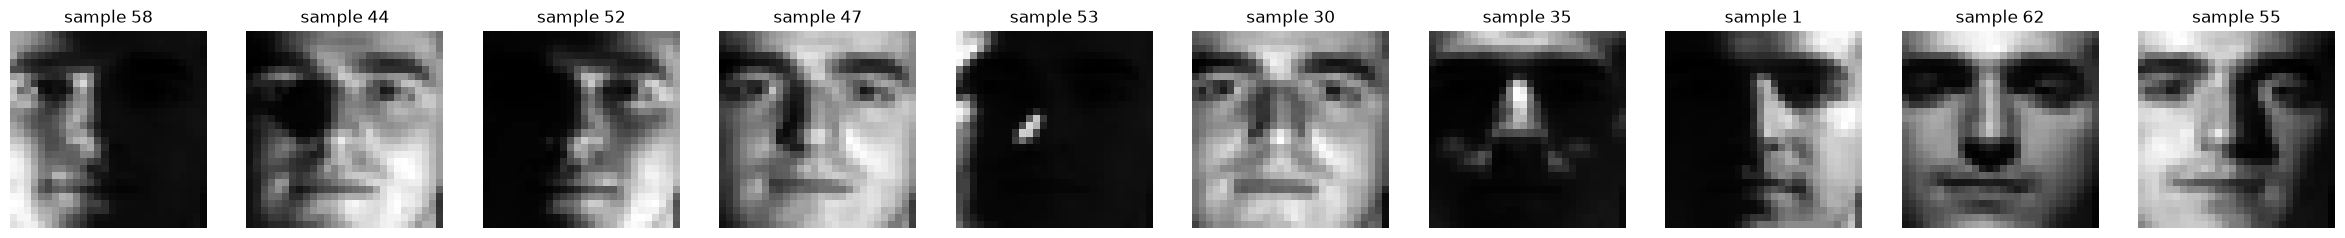

In [44]:
def filter_classes_or_individuals(classes):
    samples = []
    for c in classes:
        samples.append(X_all[y_all==c])
    return torch.vstack(samples)


## Filter out classes or individuals
## MNIST: Class 0 - 9
## YALEB: Class 0 - 37
CLASSES = [37] # MODIFY THIS LINE
# CLASSES = [0] # MODIFY THIS LINE
X = filter_classes_or_individuals(CLASSES)

# TODO: take the first xxx samples from X which will be useful for question (g)
def limit_n_samples(X, k=1_000):
    return X[:k]

X = limit_n_samples(X)

# Visualize Samples
print(f'Number of samples: {X.shape[0]}')
sample_idxs = np.random.choice(X.shape[0], 10, replace=False)
fig, ax = plt.subplots(ncols=10, figsize=(30, 5))
for i, sample_idx in enumerate(sample_idxs):
    ax[i].imshow(X[sample_idx].reshape(28, 28), cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'sample {sample_idx}')
plt.show()

## Part (a): Closed-form PPCA
Implement functions that compute the sample mean and covariance and return the closed-form PPCA estimates $(W^*, b^*, \sigma^*)$ given $X$ and latent dimension $d$. Use the formulas from class.

torch.Size([784]) torch.Size([784, 784])


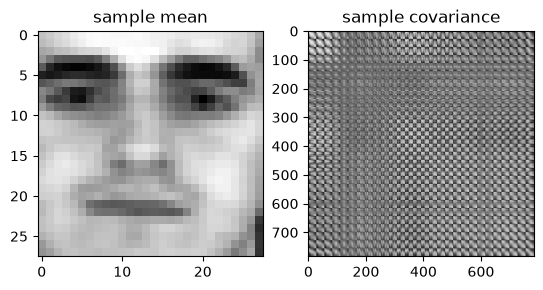

In [45]:
# Closed-form PPCA helpers
n_samples, data_dim = X.shape

# Dimension parameter d of the latent variable 
latent_dim = 2

def compute_sample_mean_cov(X: torch.Tensor):
    # X: [N, D]
    mean = torch.mean(X, dim=0)
    centered = X - mean
    cov = centered.T @ centered / X.shape[0]
    return mean, cov

# implement closed-form PPCA (return W_star, b_star, sigma_star)
def closed_form_ppca(X: torch.Tensor, d: int):
    mean, cov = compute_sample_mean_cov(X)
    
    U, S, Vh = torch.linalg.svd(cov)
    
    U_1 = U[:, :d]
    Lambda_1 = S[:d]
    Lambda_2 = S[d:]
    
    b_star = mean
    sigma_squared_star = 1 / (data_dim - d) * torch.sum(Lambda_2)
    sigma_star = sigma_squared_star.sqrt()
    W_star = U_1 @ (torch.diag(Lambda_1) - sigma_squared_star * torch.eye(d)).sqrt()
    
    return W_star, b_star, sigma_star

# quick visualization of sample stats
sample_mean, sample_covariance = compute_sample_mean_cov(X)
print(sample_mean.shape, sample_covariance.shape)

fig, ax = plt.subplots(ncols=2)
ax[0].imshow(sample_mean.view(28, 28).numpy(), cmap='gray')
ax[0].set_title('sample mean')
ax[1].imshow(sample_covariance.numpy(), cmap='gray')
ax[1].set_title('sample covariance')
plt.show()

# Closed-form solution for PPCA 
W_star, b_star, sigma_star = closed_form_ppca(X, latent_dim)

## Part (b): EM for PPCA
Implement one EM iteration mapping $(b^k, W^k, \sigma^k)$ to $(b^{k+1}, W^{k+1}, \sigma^{k+1})$ using your analytical formulas in question 2 (b). Initialize with $b^0 =0$, $W^0 =$ `first d columns of I_D`, $\sigma^0 = 0.1$. Record the data log-likelihood per iteration for later plotting.

In [46]:
# initialization is done for you
b_k = torch.zeros(data_dim)
W_k = torch.eye(data_dim)[:, :latent_dim].contiguous()
sigma_k = torch.tensor(0.1)

# implement E-step helper that returns Ez (Nxd) and EzzT (dxd)
# Ez is an N x d matrix whose j-th row is <z_j>^k defined in the equation above question 2(a)
# EzzT is the d x d matrix of \sum_{j=1}^N <z_j z_j^T>^k, defined in the equation in question 2(a) above the Hint 
def mstep_helper(X: torch.Tensor, b: torch.Tensor, W: torch.Tensor, sigma: torch.Tensor):
    # X: [N, D], b: [D], W: [D, d], sigma: scalar
    N, D = X.shape
    d = W.shape[1]
    # TODO: fill in
    M = W.T @ W + sigma ** 2 * torch.eye(d)
    Ez = (X-b) @ W @ M.inverse()
    EzzT = N * sigma ** 2 * M.inverse() + Ez.T @ Ez
    
    return Ez, EzzT

# implement M-step update
# you should use the equations in Problem 2(b)
def mstep_update(X: torch.Tensor, Ez: torch.Tensor, EzzT: torch.Tensor):
    # TODO: fill in
    N, D = X.shape
    b_next = X.mean(dim=0)
    
    # W sum(zzt) = sum (x-b) E[z]^T
    W_next = (X - b_next).T @ Ez @ EzzT.inverse()
    
    # sigma = 
    sigma_next = (1 / (N * D) * (
        (X - b_next).norm() ** 2 
        # - 2 * (X - b_next) @ W_next @ Ez
                # N by D,     D, d     N,d
        - 2 * ((X - b_next) * (Ez @ W_next.T)).sum()
        + torch.trace(W_next.T @ W_next @ EzzT)
    )).sqrt()
    
    return b_next, W_next, sigma_next

# compute log-likelihood 
def log_likelihood(X: torch.Tensor, b: torch.Tensor, W: torch.Tensor, sigma: torch.Tensor):
    # p(x) = N(b, C) where C = W W^T + sigma^2 I
    N, D = X.shape
    C = W @ W.T + (sigma ** 2) * torch.eye(D, device=W.device, dtype=W.dtype)
    X_centered = X - b[None, :]
    # Use stable log-det and solve
    L = torch.linalg.cholesky(C)
    logdetC = 2.0 * torch.sum(torch.log(torch.diag(L)))
    # Solve C^{-1} X_centered^T via chol solve
    alpha = torch.cholesky_solve(X_centered.T, L)
    quad = torch.sum(X_centered.T * alpha)
    ll = -0.5 * (N * (D * torch.log(torch.tensor(2 * np.pi, dtype=W.dtype, device=W.device)) + logdetC) + quad)
    return ll


# Example skeleton for running and logging metrics
max_iter_em = 5000
em_ll_hist = []
kl_hist_em = []
subspace_hist_em = []
b_rel_hist_em = []
sigma_rel_hist_em = []
wall_time_em = []

# EM loop
import time
em_start = time.time()
for k_em in range(max_iter_em):
    Ez, EzzT = mstep_helper(X, b_k, W_k, sigma_k)
    b_k, W_k, sigma_k = mstep_update(X, Ez, EzzT)
    # Record the log-likelihood at each iteration so you can see if it increases over iterations.
    em_ll_hist.append(float(log_likelihood(X, b_k, W_k, sigma_k)))
    # TODO: in part (d), you will implement the metrics gaussian_kl and subspace_error, then uncomment the following lines
    kl_hist_em.append(gaussian_kl(b_star, W_star @ W_star.T + sigma_star**2 * torch.eye(data_dim),
                                  b_k, W_k @ W_k.T + sigma_k**2 * torch.eye(data_dim)))
    subspace_hist_em.append(subspace_error(W_k, W_star))
    b_rel_hist_em.append(float(torch.norm(b_star - b_k) / (torch.norm(b_star) + 1e-12)))
    sigma_rel_hist_em.append(float(torch.abs(sigma_k - sigma_star) / (torch.abs(sigma_star) + 1e-12)))
    wall_time_em.append(time.time() - em_start)

## Part (c): Gradient ascent for the PPCA ELBO
Implement gradient ascent on the PPCA ELBO with respect to $(W, b, \sigma)$ and $(A, c, \Sigma_e)$ with Adam optimizer. Try multiple learning rates and record the objective per iteration for later comparison.

iteration 0 completed
iteration 1000 completed
iteration 2000 completed
iteration 3000 completed
iteration 4000 completed


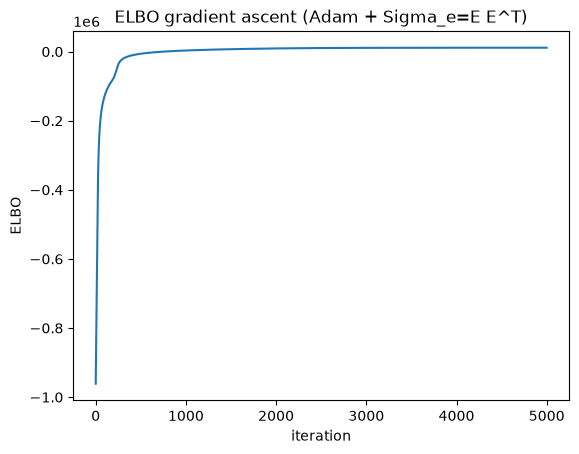

In [47]:
# max iteration 
max_iter_elbo = 5000
# adam learning rate
adam_lr = 1e-3

# TODO: implement elbo(X, W, b, sigma, A, c, Sigma_e) using analytical expression
# Since Sigma_e is a covairance matrix which must be positive-definite, we parameterize it as Sigma_e = E E^T

def elbo(X, W, b, sigma, A, c, E):
    """
    X: [N, D]
    W: [D, d]
    b: [D]
    sigma: scalar
    A: [d, D]
    c: [d]
    E: [d, d]
    """
    N, D = X.shape
    d = W.shape[1]
    # TODO: fill in
    # you may find compute_sample_mean_cov useful. 
    # mean, cov = compute_sample_mean_cov(X)
    
    mu = X @ A.T + c
    residual = X - mu @ W.T - b
    
    reconstruction = (
        - N * D / 2 * torch.log(2 * torch.pi * sigma ** 2) 
        - 1 / (2 * sigma ** 2) * (
            residual.norm() ** 2
            + N * torch.trace(W @ E @ E.T @ W.T)
        )
    )
    
    KL_divergence = 0.5 * (
        N * torch.trace(E @ E.T)
        + mu.norm() ** 2
        - N * d
        - N * torch.linalg.slogdet(E @ E.T)[1]
    )
    
    # idk why we needed compute_sample_mean_cov
    L = reconstruction - KL_divergence
    
    return L

# Initialize model and variational params
W = torch.eye(data_dim)[:, :latent_dim].contiguous().clone().requires_grad_(True)
b = torch.zeros(data_dim, requires_grad=True)
sigma = torch.tensor(0.1, requires_grad=True)
A = torch.eye(data_dim)[:latent_dim, :].contiguous().clone().requires_grad_(True)
c = torch.zeros(latent_dim, requires_grad=True)
E = torch.eye(latent_dim).clone().requires_grad_(True)

# Example skeleton for running and logging metrics
elbo_ll_hist = []
kl_hist_elbo = []
subspace_hist_elbo = []
b_rel_hist_elbo = []
sigma_rel_hist_elbo = []
wall_time_elbo = []

# TODO: add an adam optimizer to optimize the encoder and decoder parameters with learning rate adam_lr
params = [W, b, sigma, A, c, E]
optimizer = torch.optim.Adam(params, adam_lr)

elbo_start = time.time()
for k_elbo in range(max_iter_elbo):
    if k_elbo % 1000 == 0:
        print(f"iteration {k_elbo} completed")
        
    optimizer.zero_grad(set_to_none=True)
    L = elbo(X, W, b, sigma, A, c, E)

    # TODO: Here, you need to compute the loss, backpropagate (in the ascending direction of the loss), and step the optimizer 
    loss = -L
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        sigma.clamp_(min=1e-6)

    # Record the log-likelihood at each iteration so you can see if it increases over iterations.
    elbo_ll_hist.append(log_likelihood(X, b, W, sigma).detach())

    # If you want to debug, you can print loss and log likelihood at each iteration
    # print(L.item(), log_likelihood(X, b, W, sigma).item())
    
    # TODO: part (d): Record other metrics (gaussian_kl, subspace_error, b relative error, sigma relative error), then uncomment the following lines
    kl_hist_elbo.append(gaussian_kl(b_star, W_star @ W_star.T + sigma_star**2 * torch.eye(data_dim),
                                    b, W @ W.T + sigma**2 * torch.eye(data_dim)))
    subspace_hist_elbo.append(subspace_error(W, W_star))
    b_rel_hist_elbo.append(float(torch.norm(b_star - b) / (torch.norm(b_star) + 1e-12)))
    sigma_rel_hist_elbo.append(float(torch.abs(sigma - sigma_star) / (torch.abs(sigma_star) + 1e-12)))
    wall_time_elbo.append(time.time() - elbo_start)

plt.figure()
plt.plot(elbo_ll_hist)
plt.xlabel('iteration')
plt.ylabel('ELBO')
plt.title('ELBO gradient ascent (Adam + Sigma_e=E E^T)')
plt.show()

## Sanity check
Below, one can evaluate the log likelihood function at the closed-form solution (i.e., a global maximizer), EM output, and ELBO output. We can also evaluate the ELBO variational objective function at the closed-form encoder-decoder parameters.  If the likelihood function, the closed-form solution, and the elbo functions are implemented correctly, we should observe true_ll = true_elbo. If EM and ELBO converge, then em_ll and elbo_ll should be close to true_ll. 


In [48]:
true_ll = log_likelihood(X, b_star, W_star, sigma_star)
print("Optimal log likelihood (using closed-form solution): ", true_ll.item())

em_ll = log_likelihood(X, b_k, W_k, sigma_k)
print("EM log likelihood: ", em_ll.item())

elbo_ll = log_likelihood(X, b, W, sigma)
print("ELBO log likelihood: ", elbo_ll.item())

# variational parameters that optimize the ELBO
d = W_star.shape[1]
I_d = torch.eye(d, device=W_star.device, dtype=W_star.dtype)
M = W_star.T @ W_star + (sigma_star**2) * I_d
A_star = torch.linalg.inv(M) @ W_star.T
c_star = -A_star @ b_star
Sigma_e_star = (sigma_star**2) * torch.linalg.inv(M)
E_star = torch.linalg.cholesky(0.5 * (Sigma_e_star + Sigma_e_star.T) + 1e-6 * torch.eye(Sigma_e_star.shape[0], device=Sigma_e_star.device, dtype=Sigma_e_star.dtype))

true_elbo = elbo(X, W_star, b_star, sigma_star, A_star, c_star, E_star)
print("ELBO variational objective with optimal encoders and decoders: ", true_elbo.item())


Optimal log likelihood (using closed-form solution):  11583.67578125
EM log likelihood:  11583.669921875
ELBO log likelihood:  11387.107421875
ELBO variational objective with optimal encoders and decoders:  11583.6845703125


## Another sanity check & Part (e): Sampling from a learned PPCA model
Part (e) includes sampling from a learned PPCA model. We put the code here for convenience, and further to allow you to visualize the learned PPCA models to see if they make sense. 

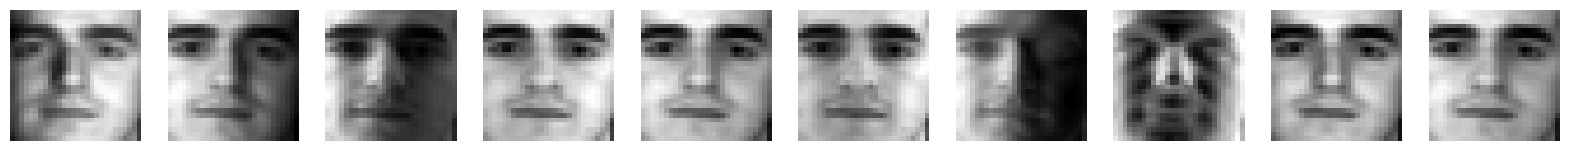

In [49]:
# TODO: Fill in b_estimate, W_estimate, z, eps. You need to use the output of one of the methods (i.e., closed-form or EM or ELBO). 

# W_star, b_star, sigma_star

# sample and generate from latent space
X_sampled = []
N_SAMPLES = 10

b_estimate = b_star
W_estimate = W_star

for j in range(N_SAMPLES):
    z = torch.randn(latent_dim, 1)
    eps = torch.randn(data_dim, 1) * sigma_star
    
    # generate sample for X
    # X_sampled_j = b_estimate[:, None] + W_estimate @ z + eps
    X_sampled_j = b_estimate[:, None] + W_estimate @ z
    X_sampled.append(X_sampled_j.view(28, 28))
    

# visualize sampled X
fig, ax = plt.subplots(ncols=10, figsize=(20, 3))
for j in range(N_SAMPLES):
    ax[j].imshow(X_sampled[j], cmap='gray')
    ax[j].axis('off')
plt.show()

## Part (d): Evaluation metrics and plots (MNIST and YaleB)

For EM and ELBO runs, produce plots with iteration on the x-axis and the following metrics on the y-axis (different curves per method):
- Log-likelihood
- Gaussian-to-Gaussian KL divergence to the closed-form fit
- W-subspace error (largest principal angle)
- b-relative error and sigma-relative error
- Wall-clock timing (per-iteration and cumulative)

Closed-form may be shown as a horizontal reference line where applicable.


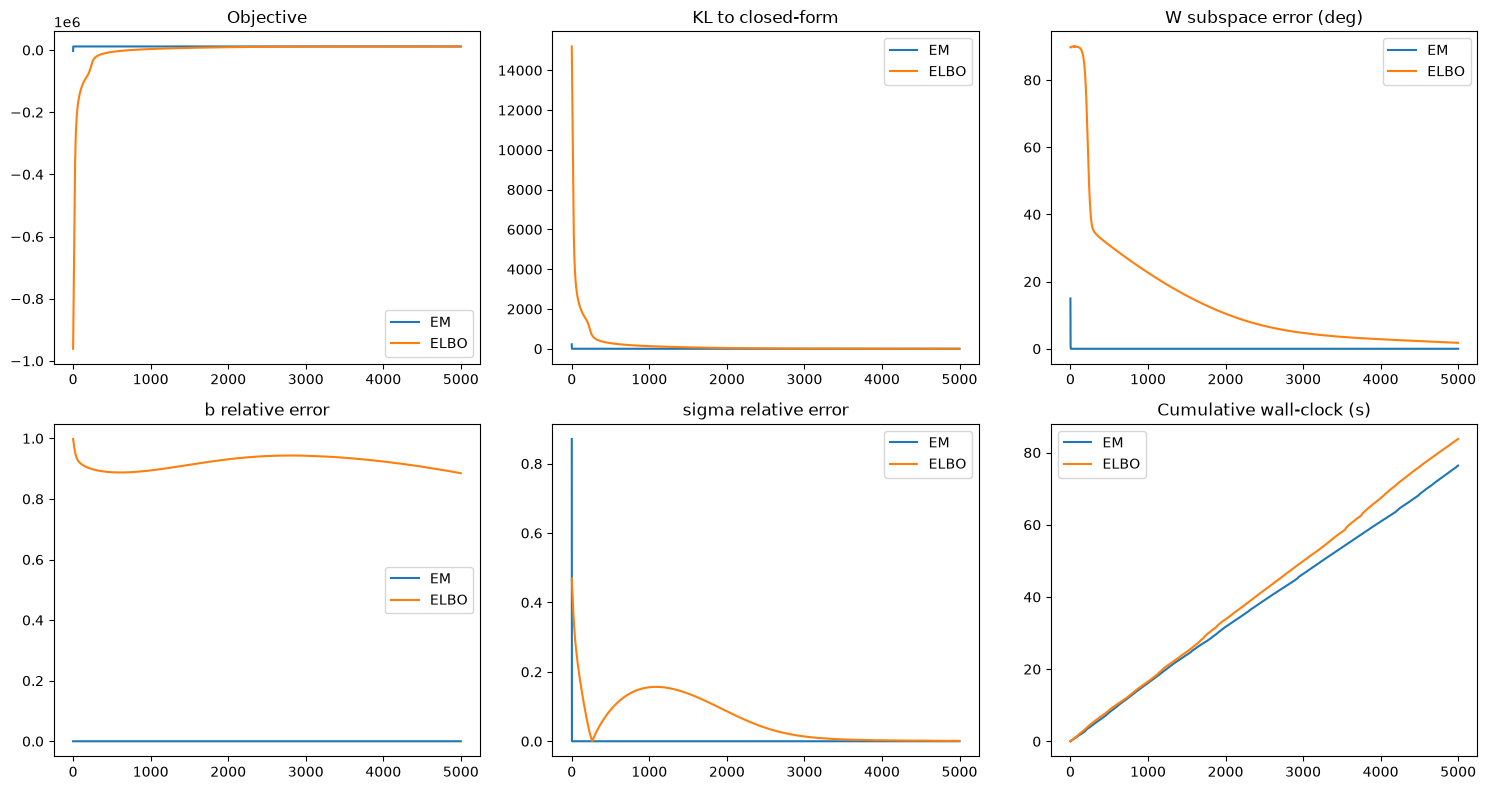

In [50]:
import time
from scipy.linalg import subspace_angles

def gaussian_kl(mu_p, Sigma_p, mu_q, Sigma_q):
    """KL divergence KL(N_p || N_q) for two Gaussians.
    """
    # TODO: fill in
    d = mu_p.numel()
    
    _, logdet_p = torch.linalg.slogdet(Sigma_p)
    _, logdet_q = torch.linalg.slogdet(Sigma_q)
    
    kl = 0.5 * (
        logdet_q - logdet_p
        - d
        + torch.trace(Sigma_q.inverse() @ Sigma_p)
        + (mu_p - mu_q).T @ Sigma_q.inverse() @ (mu_p - mu_q)
    )
    return float(kl.item())


def subspace_error(W_est, W_ref):
    """Largest principal angle in degrees between column-spaces of W_est and W_ref."""
    # TODO: fill in
    from scipy import linalg
    angles = linalg.subspace_angles(W_est.detach().numpy(), W_ref.detach().numpy())
    largest = angles.max()
    return float(np.degrees(largest))

# Feel free to change the plotting and scales to make the plots more informative and nice
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
axes[0].plot(em_ll_hist, label='EM')
axes[0].plot(elbo_ll_hist, label='ELBO')
axes[0].set_xlim()
axes[0].set_title('Objective')
axes[0].legend()

axes[1].plot(kl_hist_em, label='EM')
axes[1].plot(kl_hist_elbo, label='ELBO')
axes[1].set_title('KL to closed-form')
axes[1].legend()

axes[2].plot(subspace_hist_em, label='EM')
axes[2].plot(subspace_hist_elbo, label='ELBO')
axes[2].set_title('W subspace error (deg)')
axes[2].legend()

axes[3].plot(b_rel_hist_em, label='EM')
axes[3].plot(b_rel_hist_elbo, label='ELBO')
axes[3].set_title('b relative error')
axes[3].legend()

axes[4].plot(sigma_rel_hist_em, label='EM')
axes[4].plot(sigma_rel_hist_elbo, label='ELBO')
axes[4].set_title('sigma relative error')
axes[4].legend()

axes[5].plot(wall_time_em, label='EM')
axes[5].plot(wall_time_elbo, label='ELBO')
axes[5].set_title('Cumulative wall-clock (s)')
axes[5].legend()
plt.tight_layout()
plt.show()

In [1]:
from ppca_experiment_helpers import run_experiment, DEFAULT_CONFIG, sample_models

CONFIG = {
    **DEFAULT_CONFIG,
    "dataset": "MNIST",
    "root": "../../data",
    "classes": [0],
    "limit_n_samples": 1000,
    "latent_dimension": 2,
    "noise_level": 0.0,
    "n_generated": 10,
    "em_iterations": 5000,
    "elbo_iterations": 5000,
    "learning_rate": 1e-3,
    "metric_every": 50,
    "plot_start": 500,
    "seed": 0,
}

## Part (e): Effect of noise level
For each method, use the estimated parameters to define a PPCA model, sample from it and visualize the samples. Vary the noise level and describe the quality of the image generation.


MNIST | N=1000, D=784, d=2
Class counts: {0: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -443425.373633; per sample: -443.425374
EM           log-likelihood: -443425.373633; per sample: -443.425374
ELBO         log-likelihood: -497645.384574; per sample: -497.645385
Reference exact-posterior ELBO: -443425.373633; LL gap: -5.82e-11
Learned encoder ELBO: -497907.246453


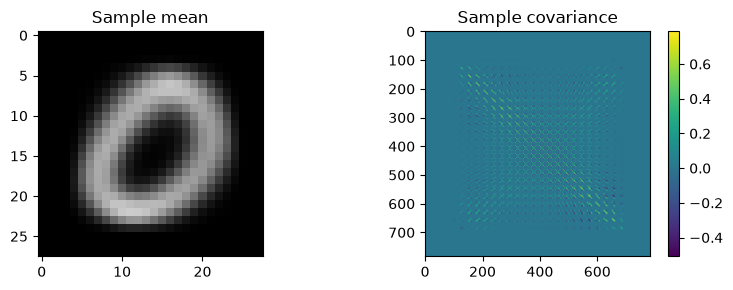

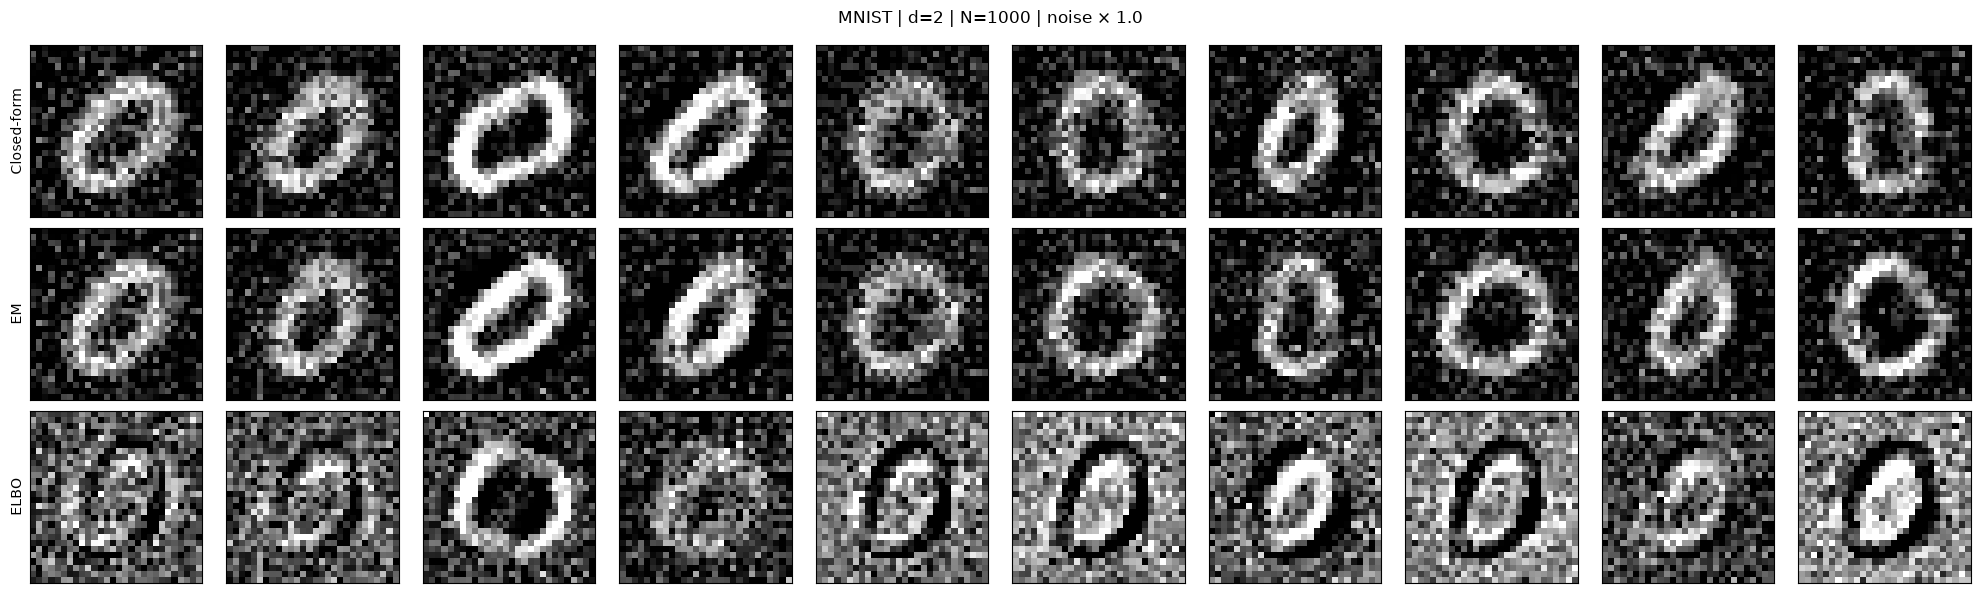

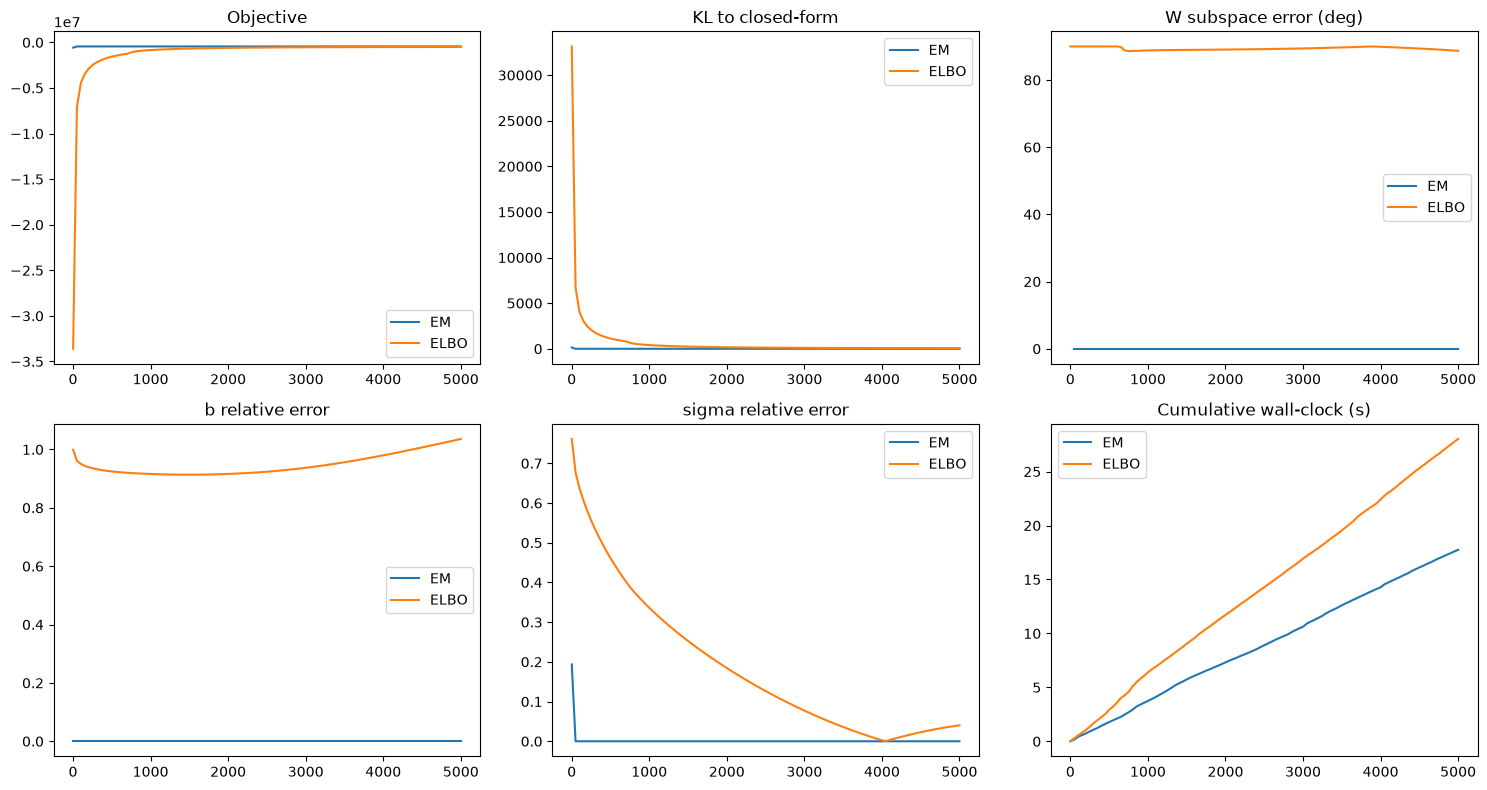

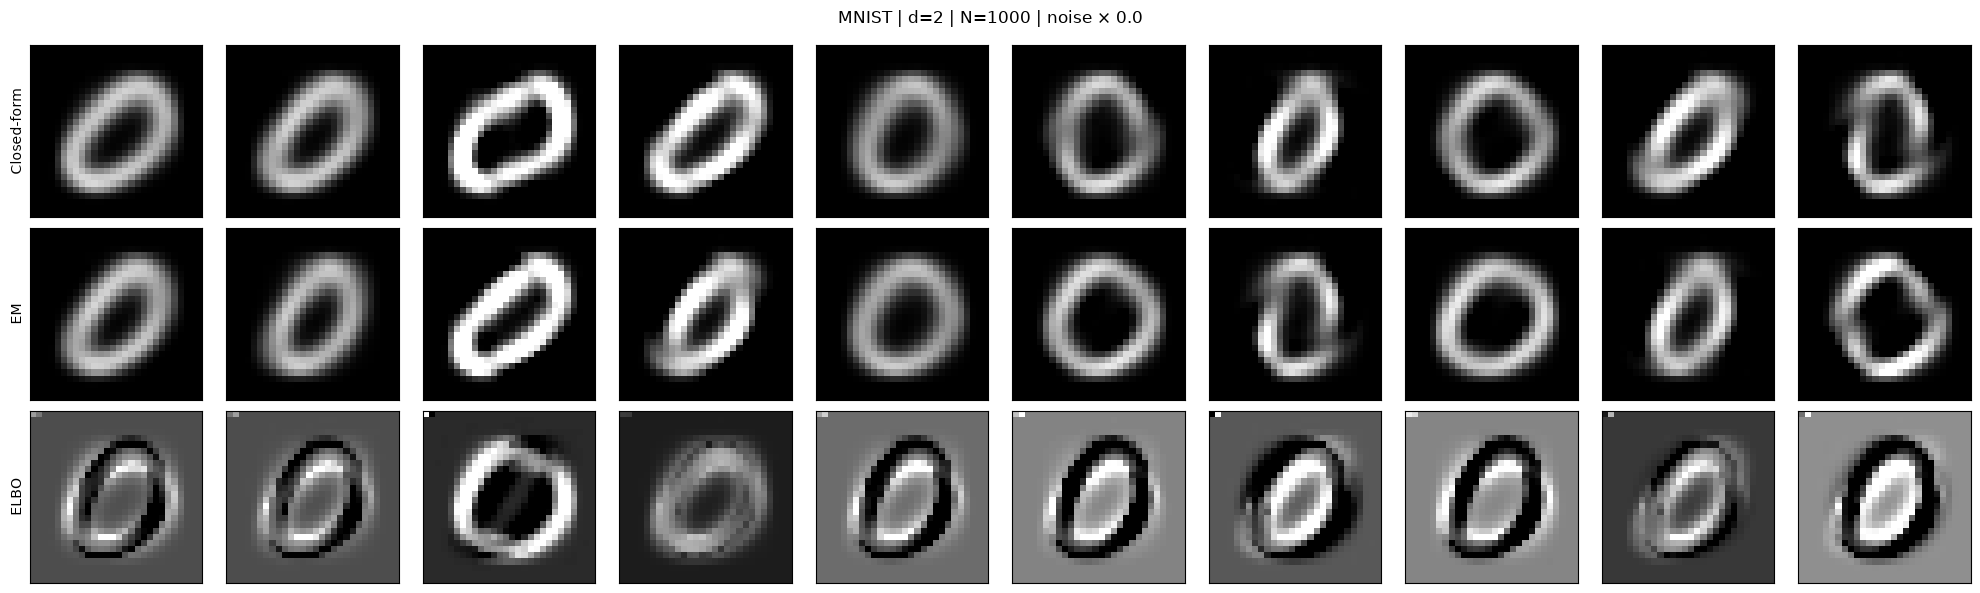

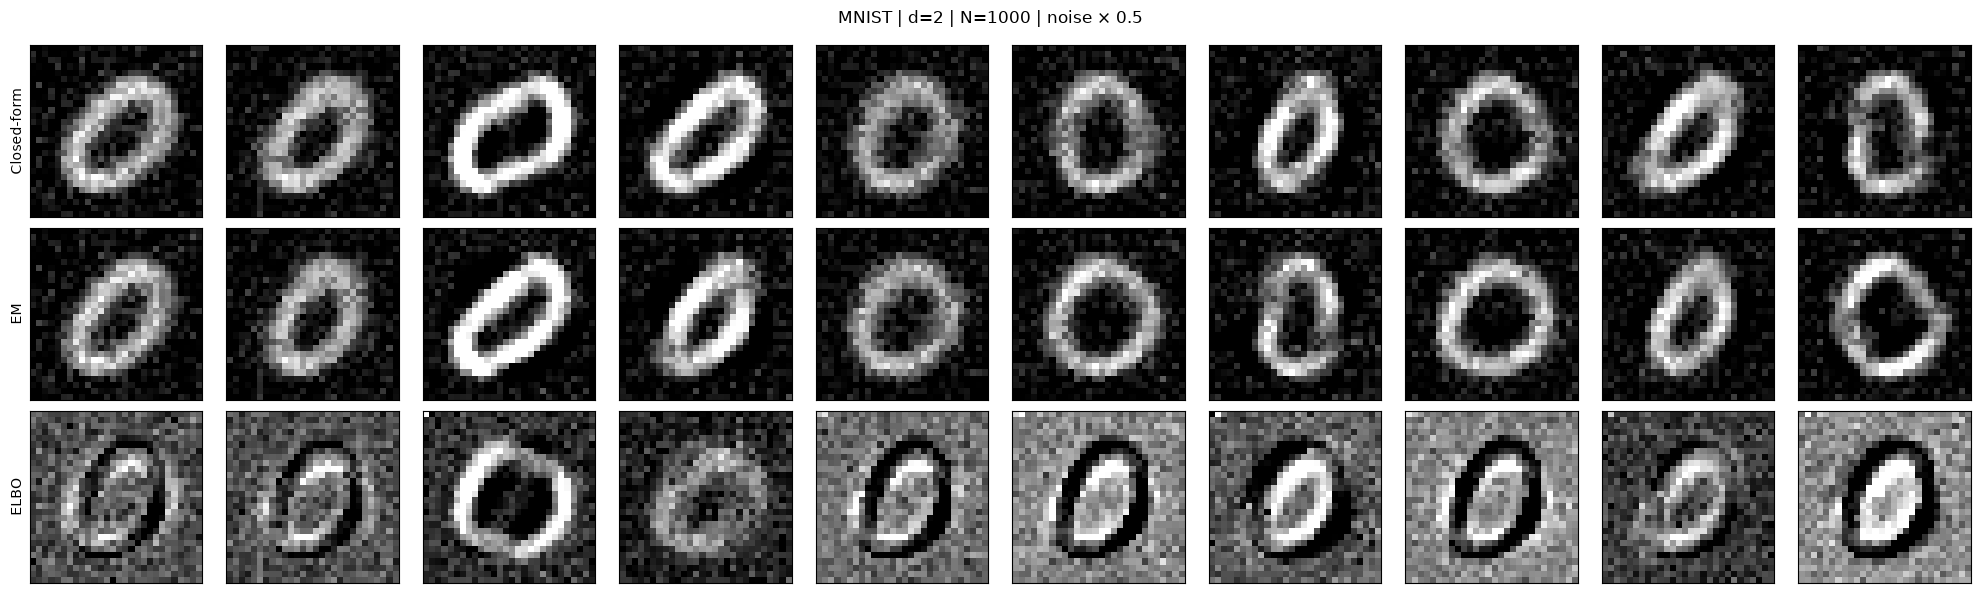

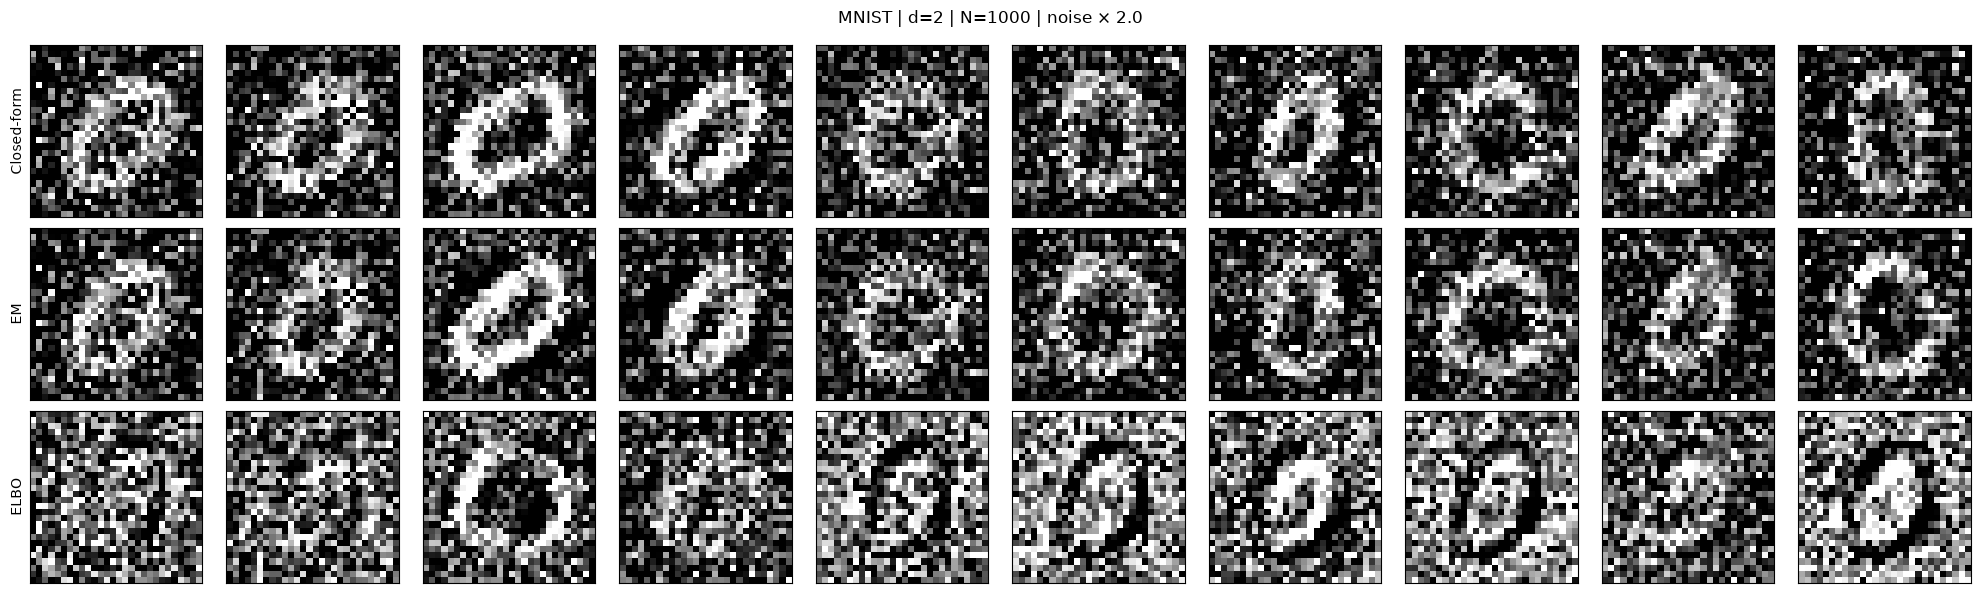

In [3]:
result_e = run_experiment({**CONFIG, "noise_level": 1.0})
samples_e = {1.0: result_e["samples"]}
for noise_level in [0.0, 0.5, 2.0]:
    samples_e[noise_level] = sample_models(result_e, noise_level=noise_level)

## Part (f): Effect of latent dimension $d$
Describe the quality of generation with respect to $d$.


MNIST | N=1000, D=784, d=1
Class counts: {0: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -504865.454828; per sample: -504.865455
EM           log-likelihood: -504865.454828; per sample: -504.865455
ELBO         log-likelihood: -547948.702622; per sample: -547.948703
Reference exact-posterior ELBO: -504865.454828; LL gap: 1.16e-10
Learned encoder ELBO: -547948.900649


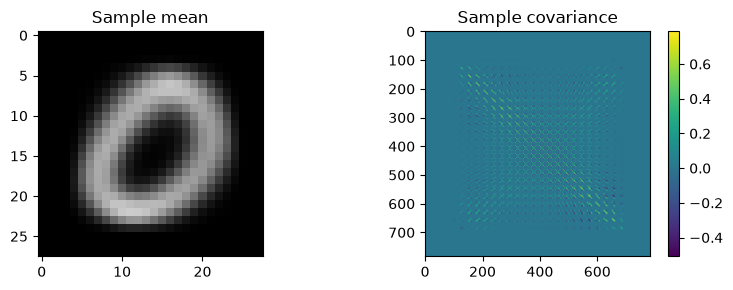

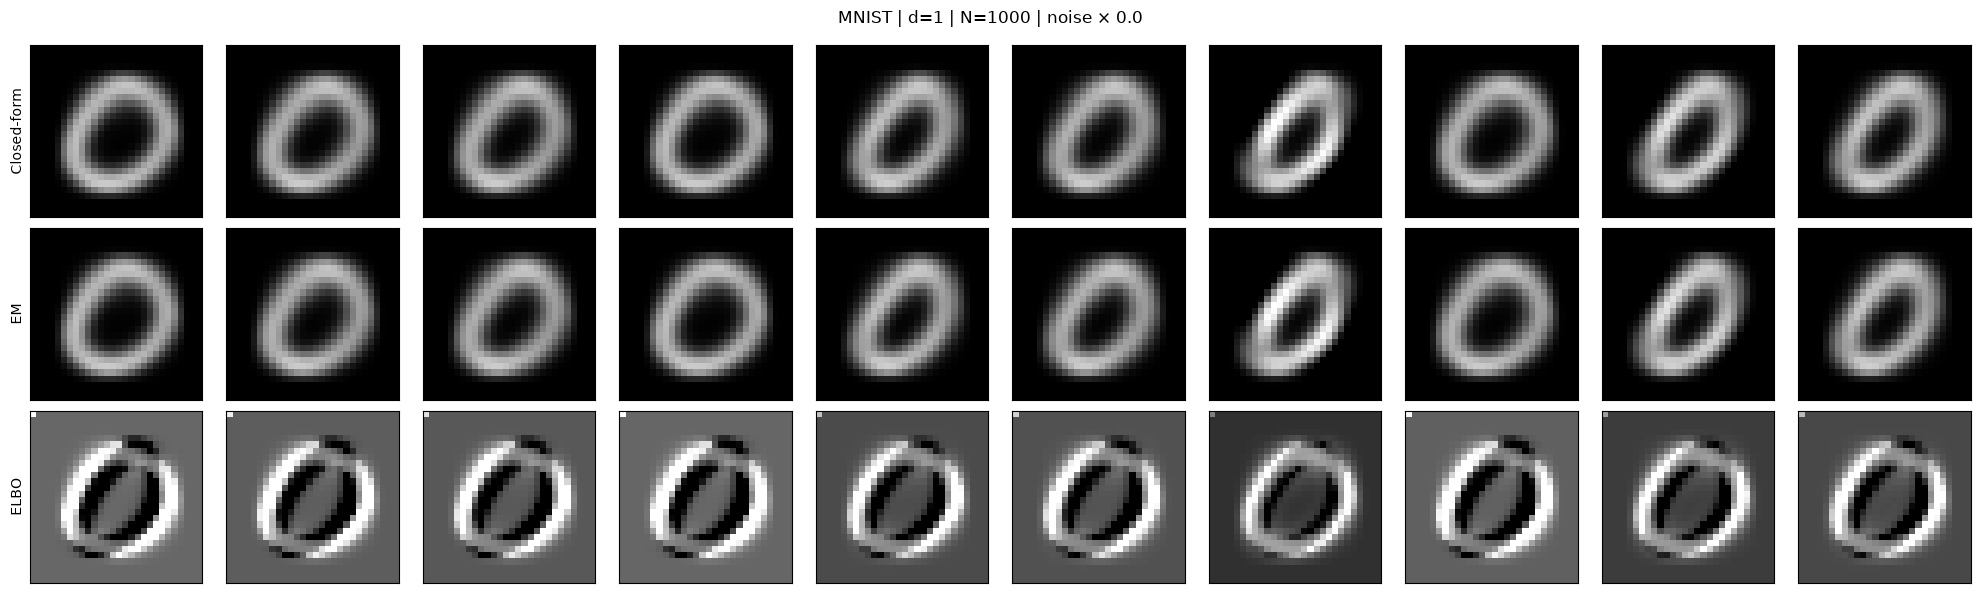

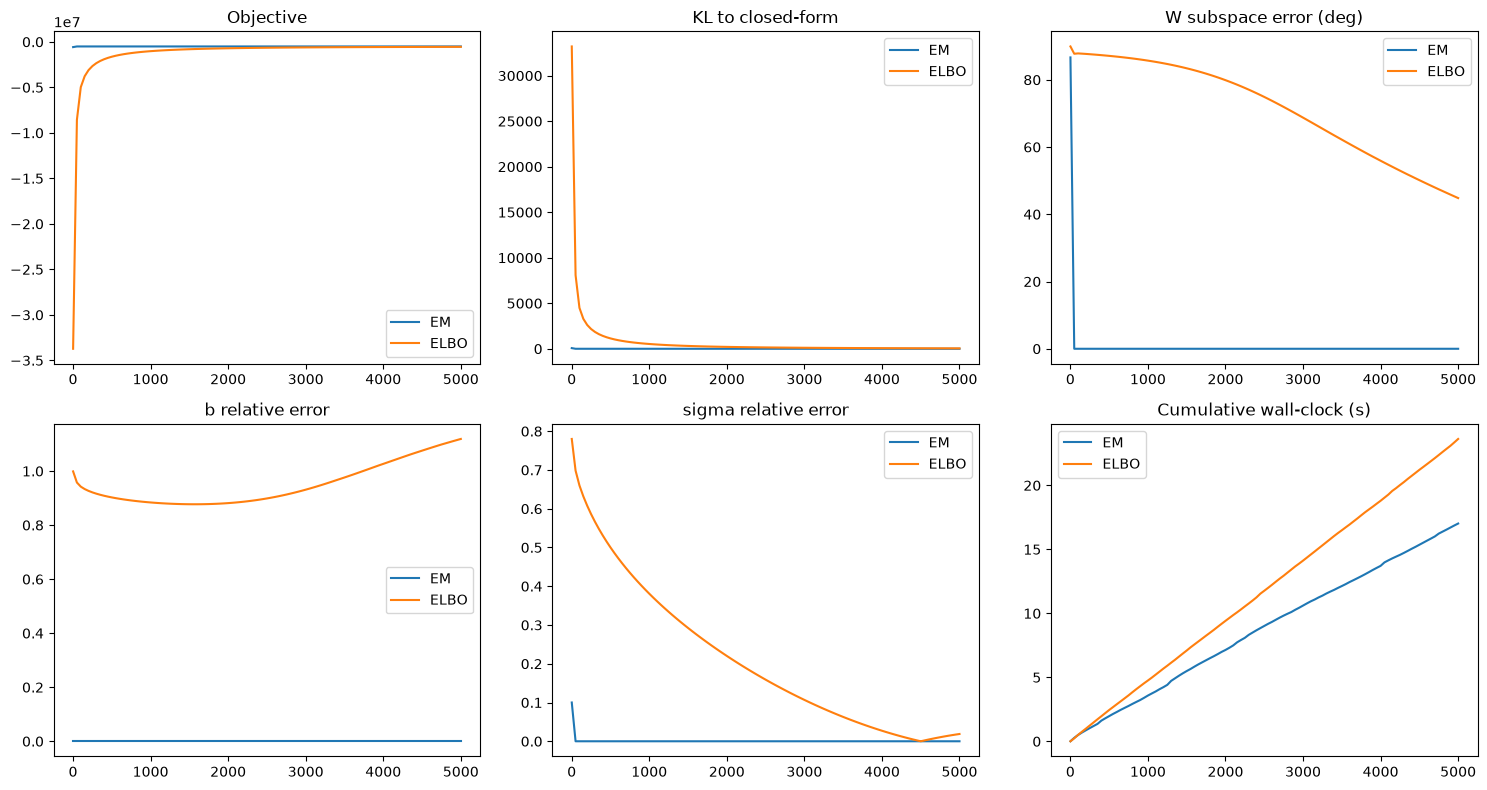


MNIST | N=1000, D=784, d=2
Class counts: {0: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -443425.373633; per sample: -443.425374
EM           log-likelihood: -443425.373633; per sample: -443.425374
ELBO         log-likelihood: -497645.384574; per sample: -497.645385
Reference exact-posterior ELBO: -443425.373633; LL gap: -5.82e-11
Learned encoder ELBO: -497907.246453


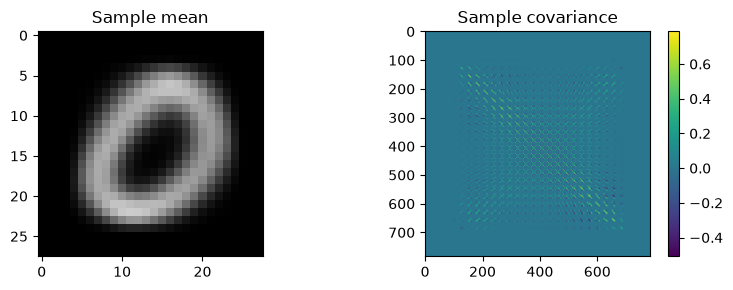

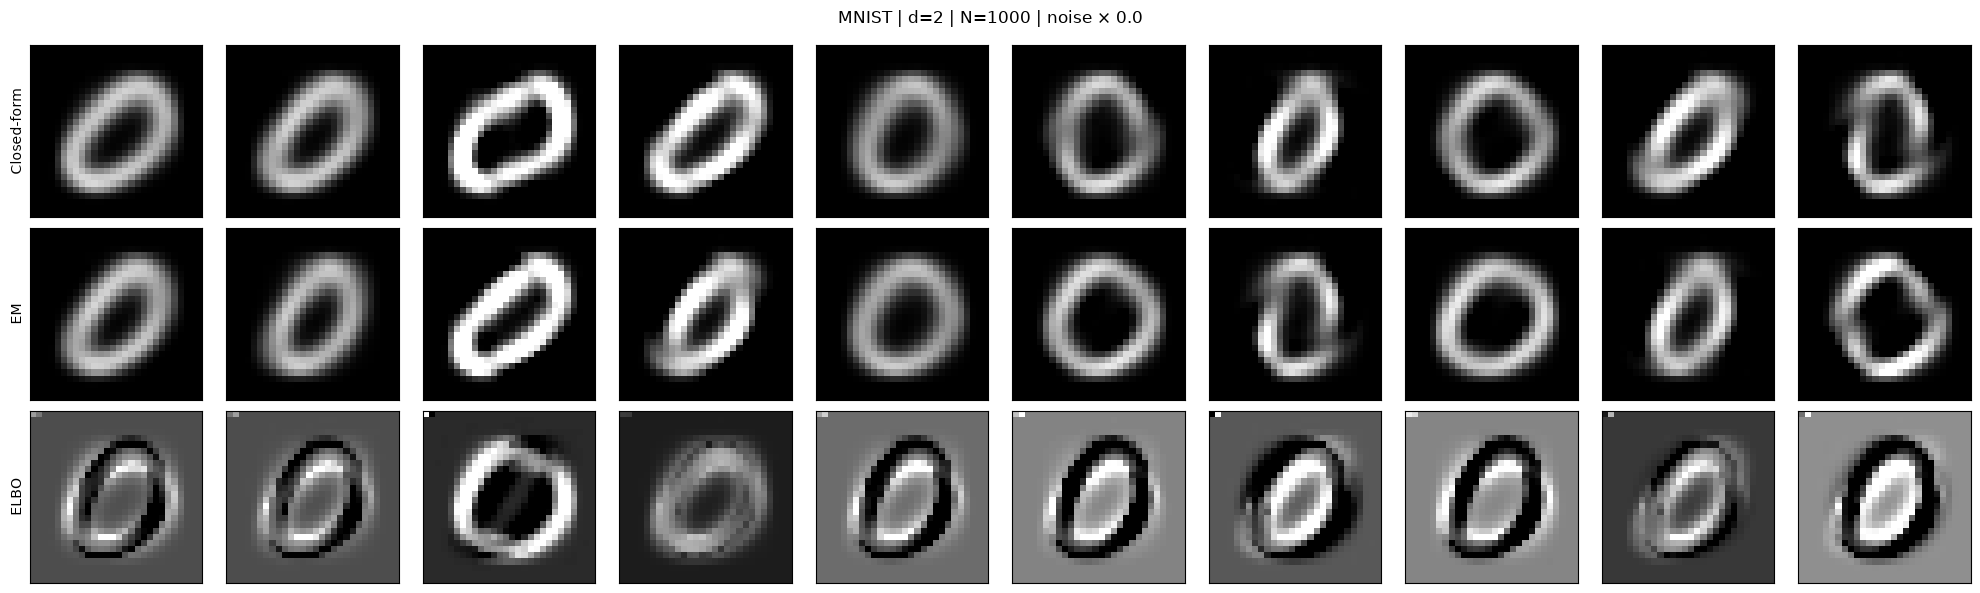

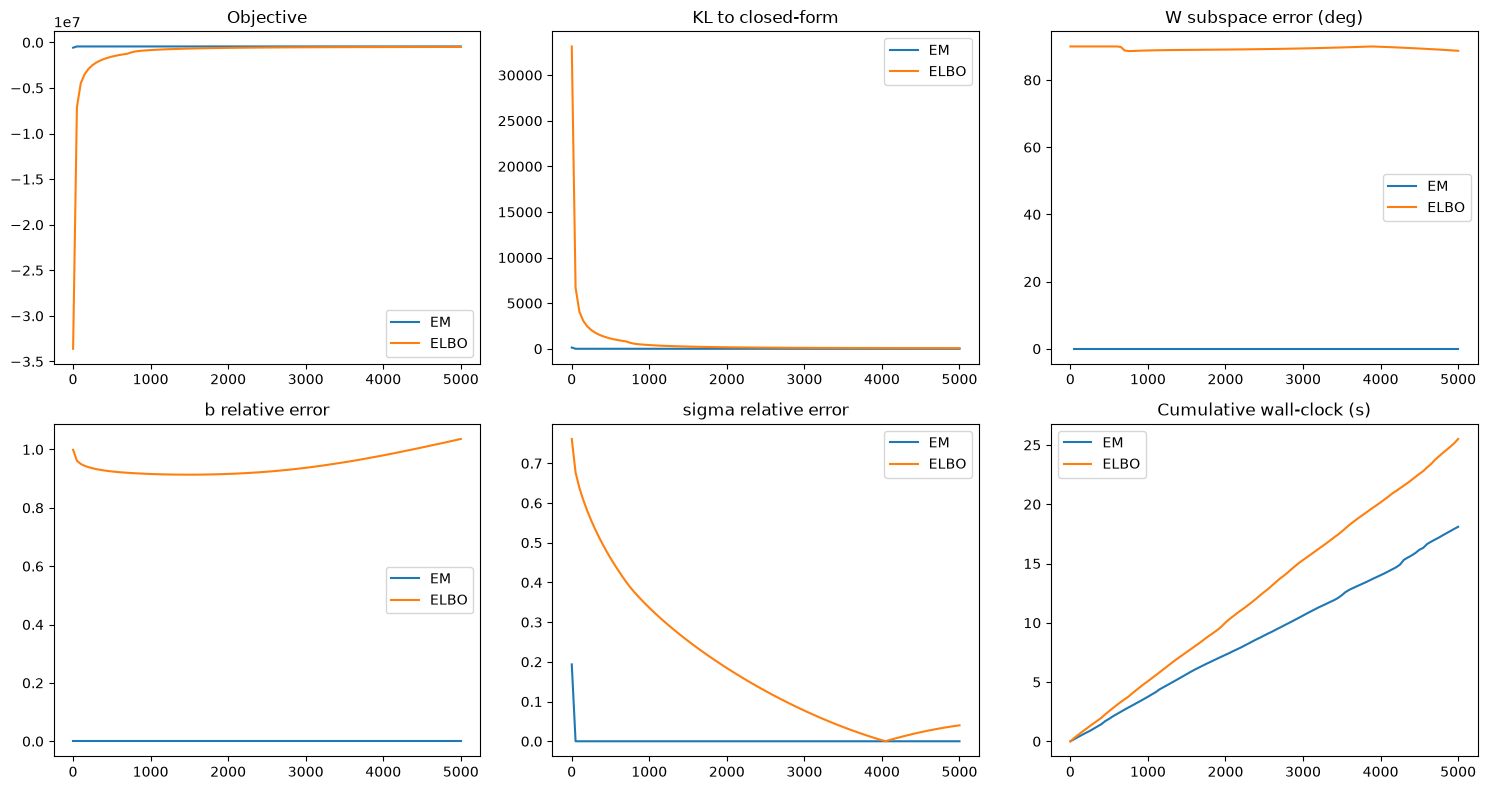


MNIST | N=1000, D=784, d=5
Class counts: {0: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -330410.699839; per sample: -330.410700
EM           log-likelihood: -330410.699839; per sample: -330.410700
ELBO         log-likelihood: -363575.118920; per sample: -363.575119
Reference exact-posterior ELBO: -330410.699839; LL gap: 1.16e-10
Learned encoder ELBO: -363584.648188


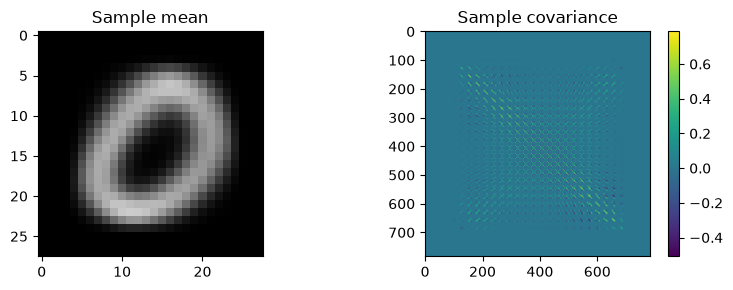

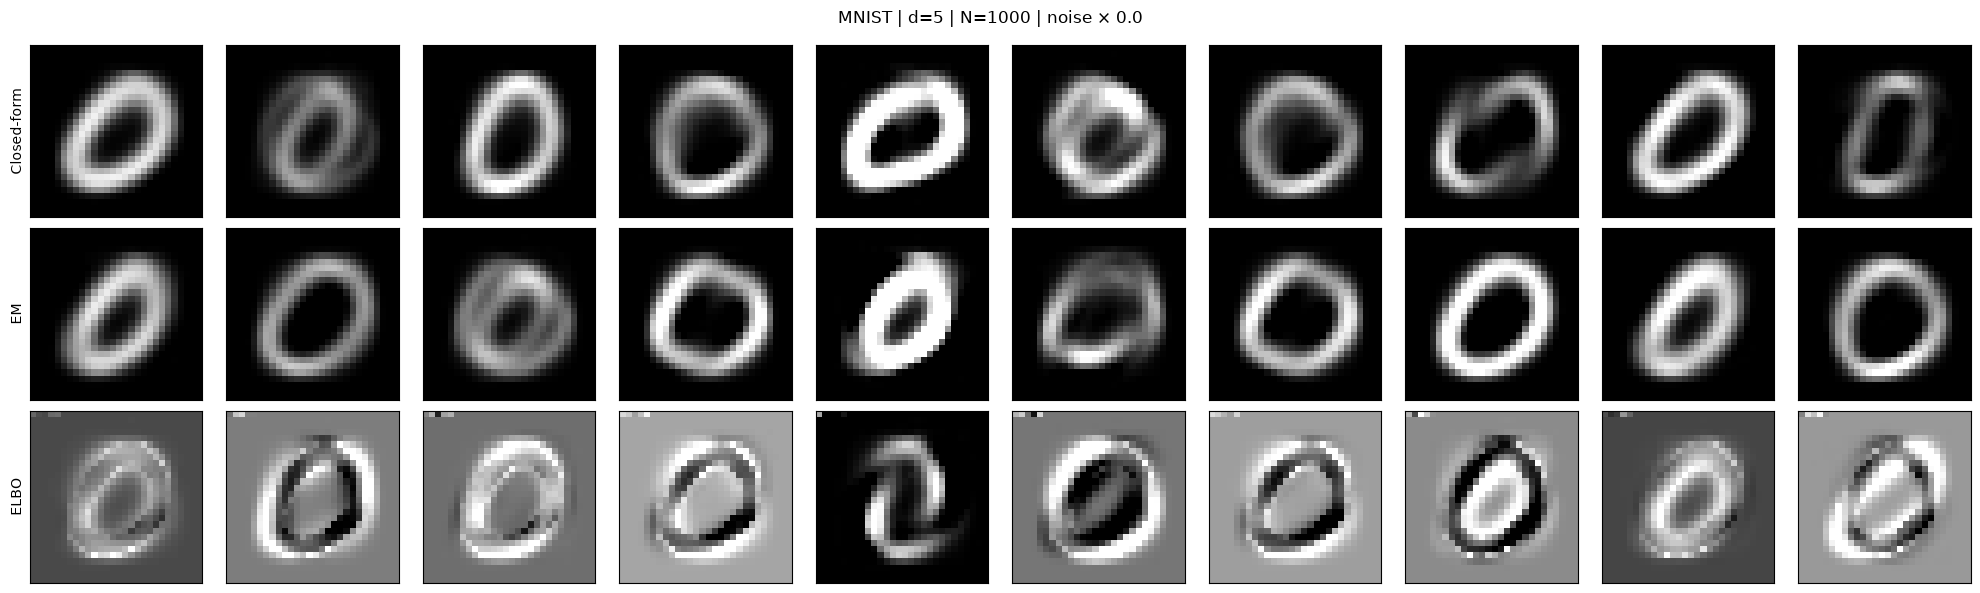

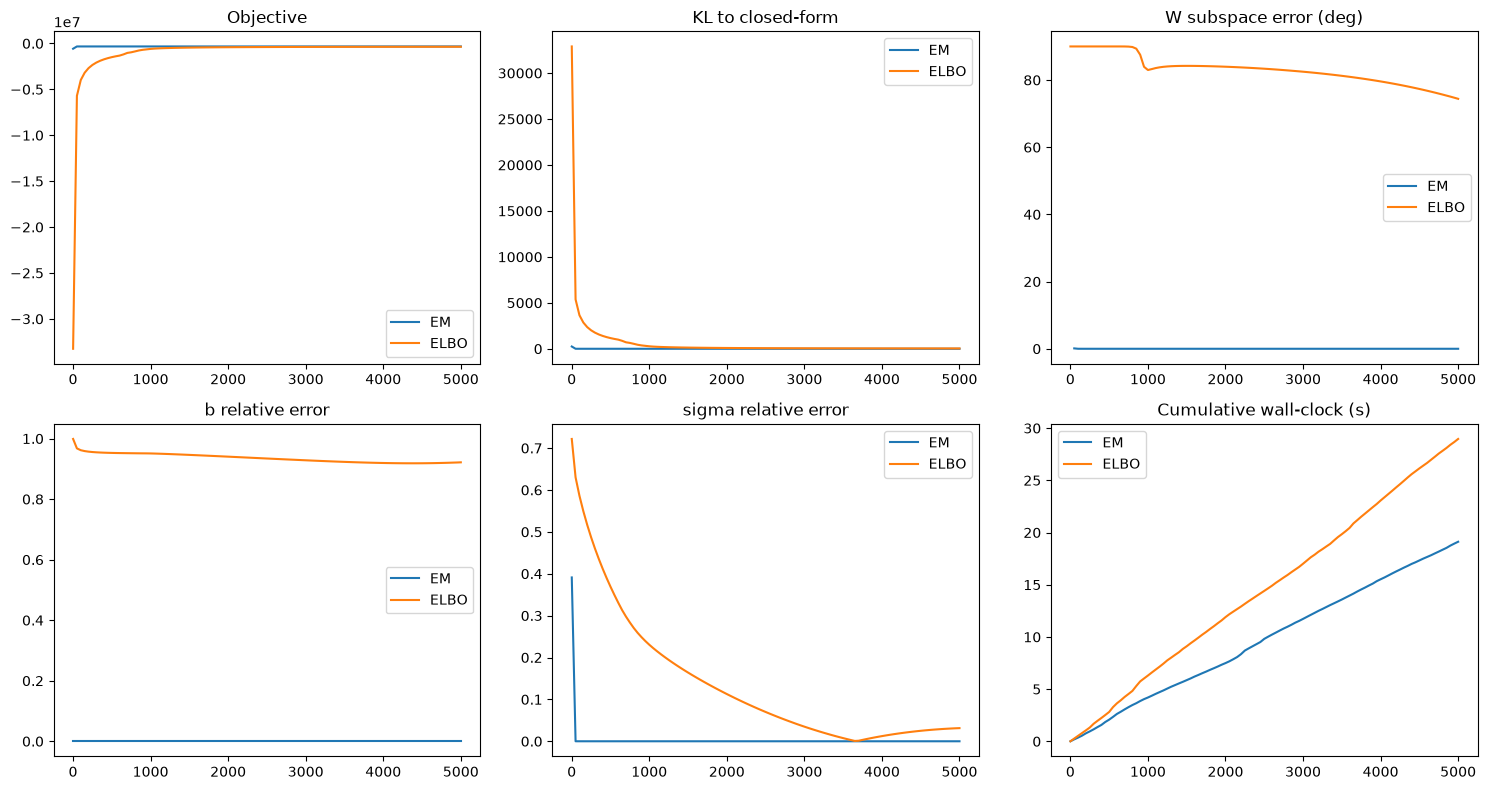


MNIST | N=1000, D=784, d=10
Class counts: {0: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -216785.960566; per sample: -216.785961
EM           log-likelihood: -216785.960566; per sample: -216.785961
ELBO         log-likelihood: -245316.381112; per sample: -245.316381
Reference exact-posterior ELBO: -216785.960566; LL gap: -2.91e-11
Learned encoder ELBO: -246593.754061


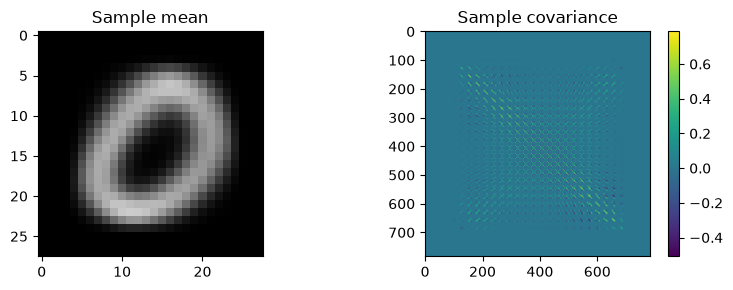

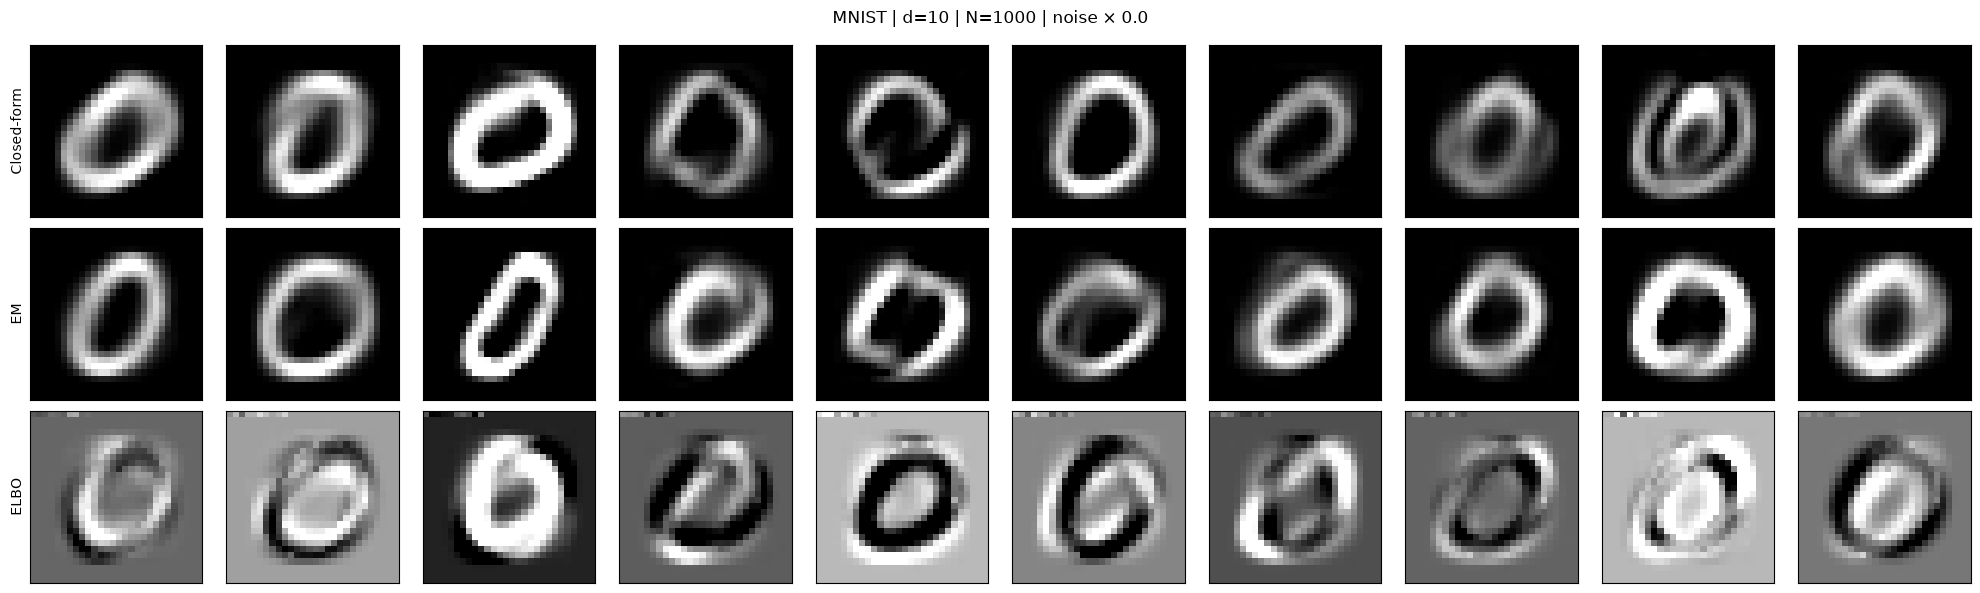

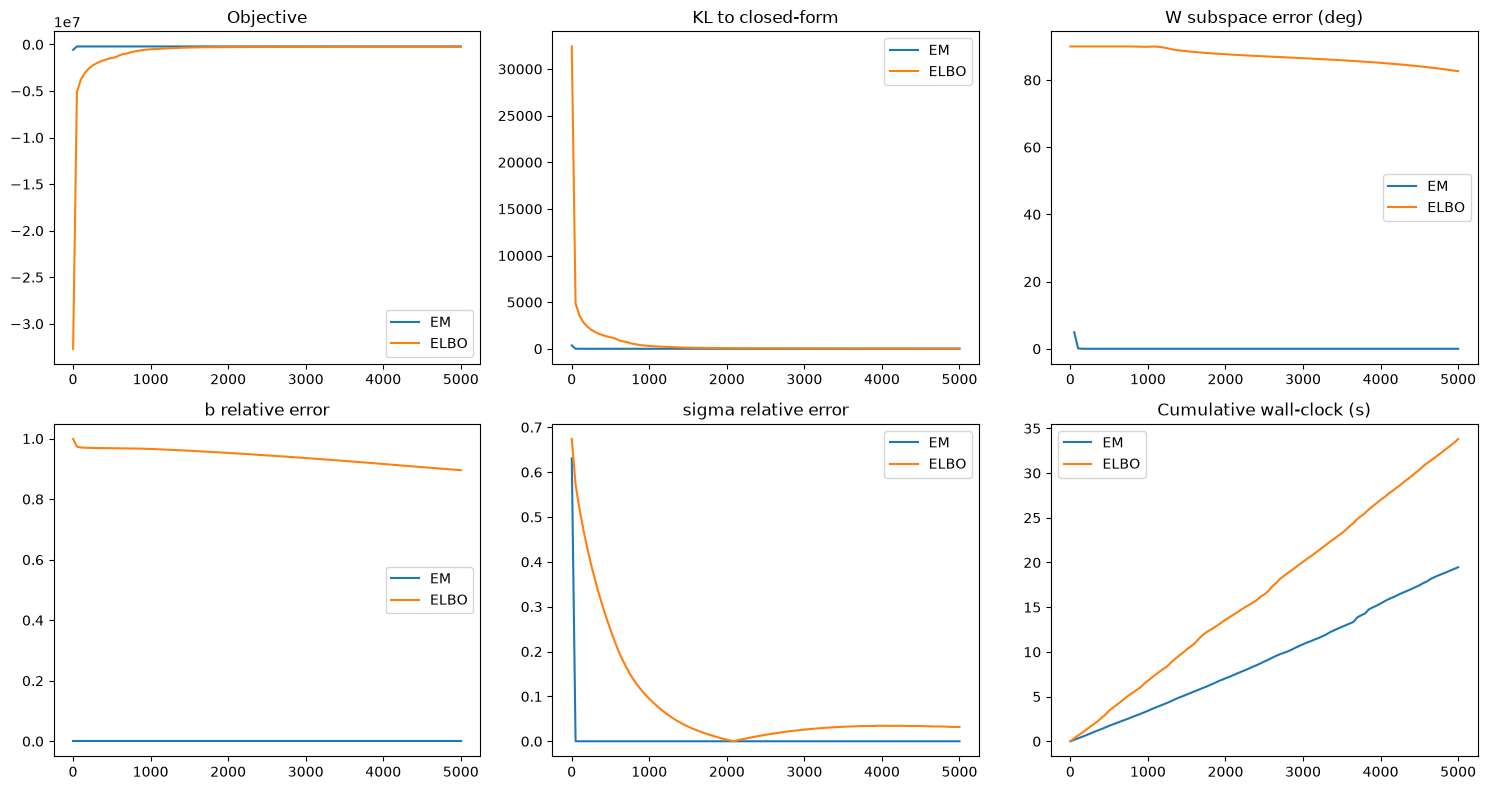

In [4]:
results_f = {}
for d in [1, 2, 5, 10]:
    results_f[d] = run_experiment({**CONFIG, "latent_dimension": d})

## Part (g): Effect of sample size $N$
Keep $d$ fixed. Compare the performance when using many samples ($N \gg d$), a moderate number of samples ($N = d$), and a small number of samples $N < d$.


YALEB | N=50, D=784, d=5
Class counts: {37: 50}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: 33709.664980; per sample: 674.193300
EM           log-likelihood: 33705.449882; per sample: 674.108998
ELBO         log-likelihood: 33378.172753; per sample: 667.563455
Reference exact-posterior ELBO: 33709.664980; LL gap: -1.46e-11
Learned encoder ELBO: 33377.689553


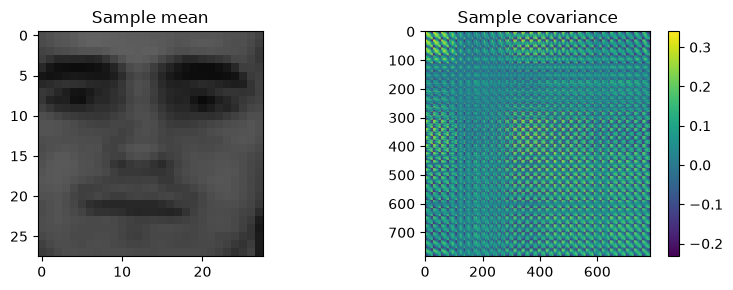

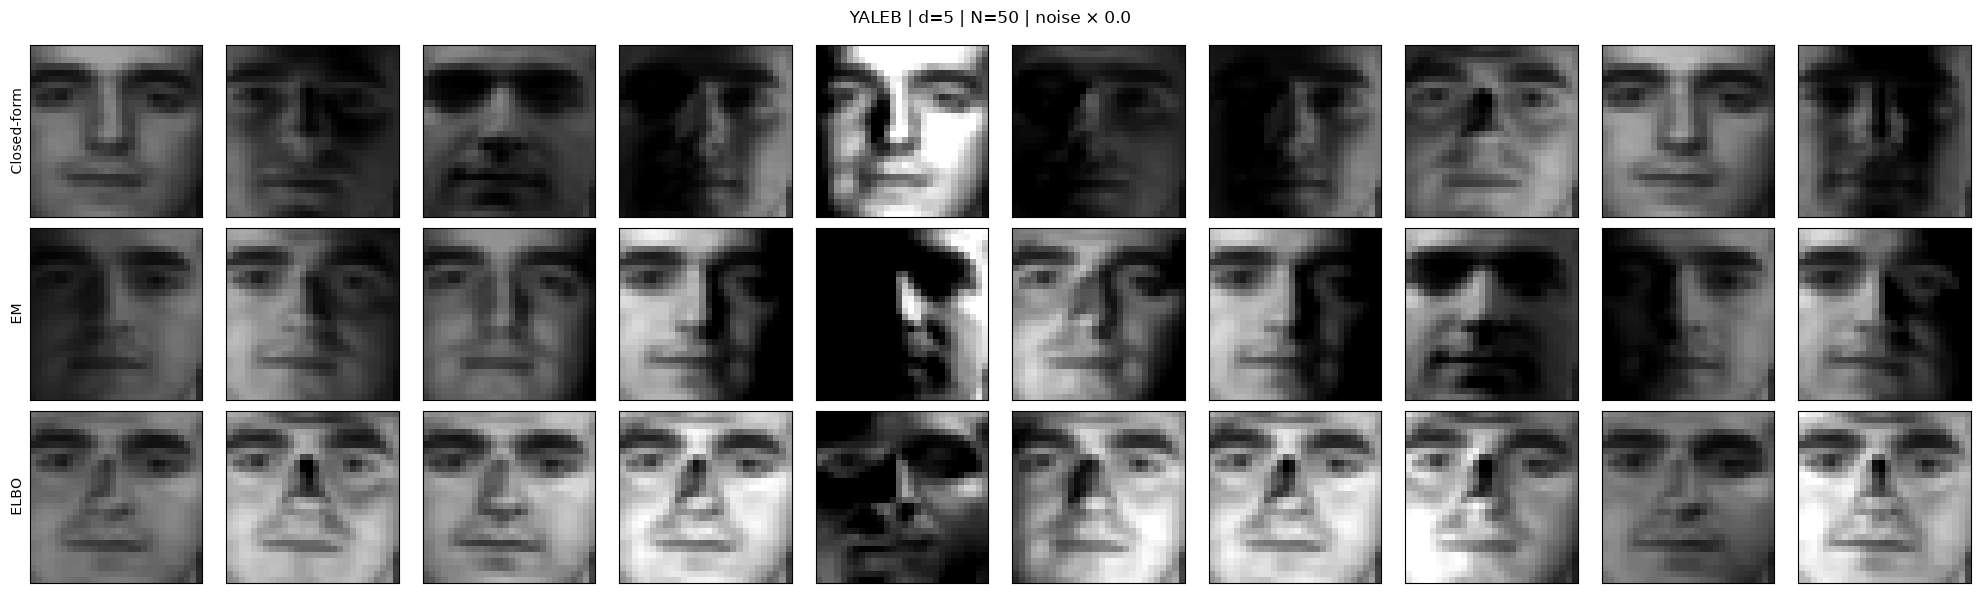

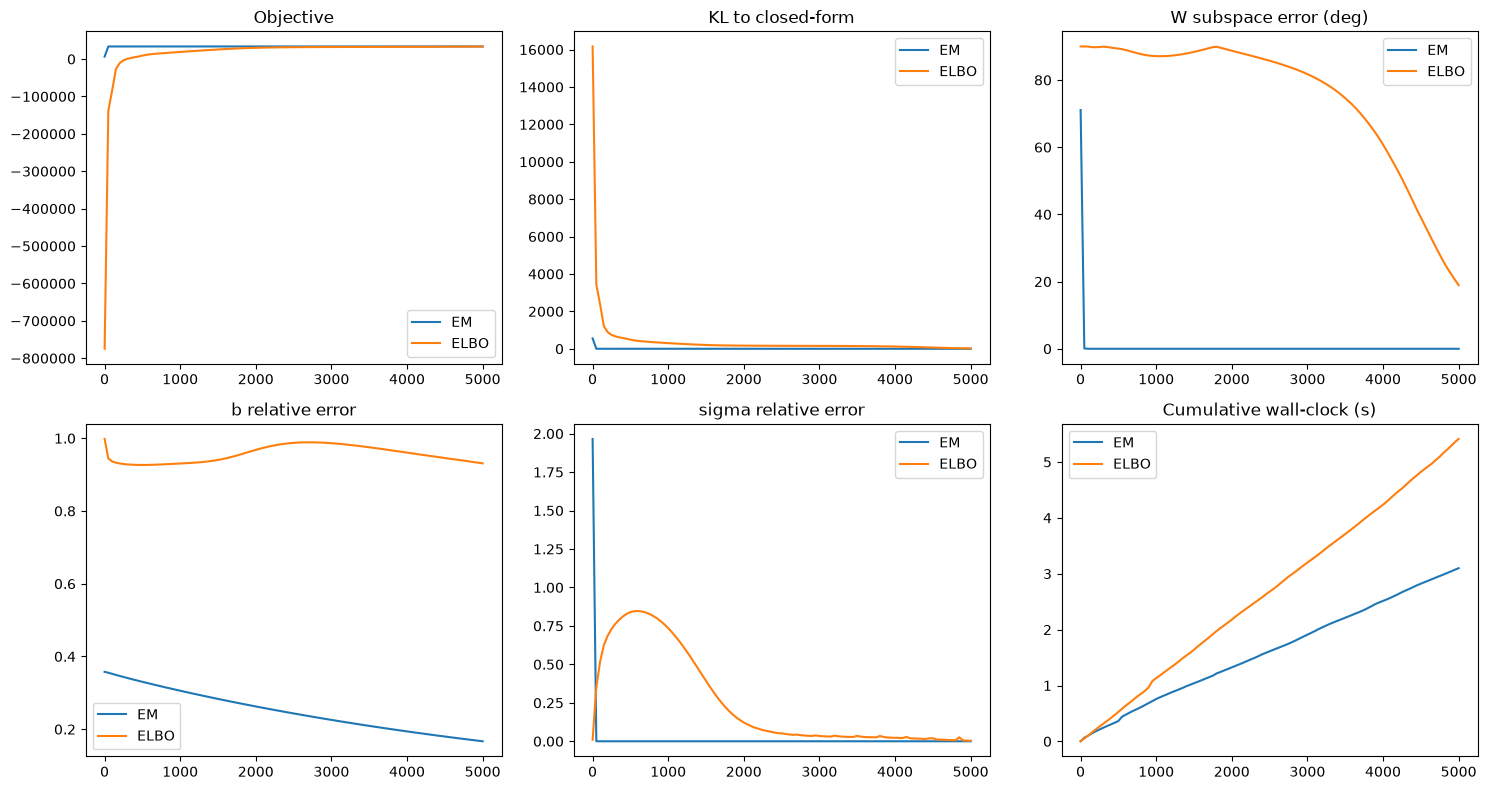


YALEB | N=5, D=784, d=5
Class counts: {37: 5}
Noise floor active: reference is a constrained fit, not a finite unconstrained MLE.
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: 32282.655261; per sample: 6456.531052
EM           log-likelihood: 32270.343924; per sample: 6454.068785
ELBO         log-likelihood: 7316.335424; per sample: 1463.267085
Reference exact-posterior ELBO: 32282.655261; LL gap: 6.21e-07
Learned encoder ELBO: 7314.334351


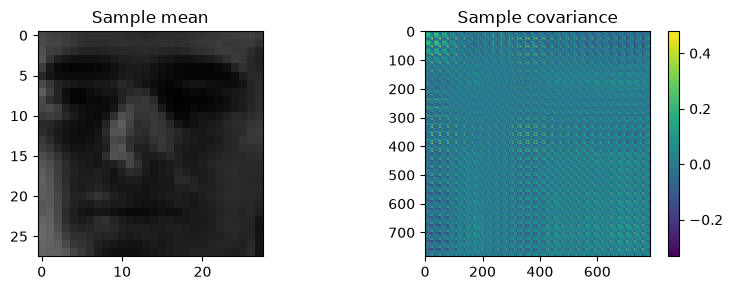

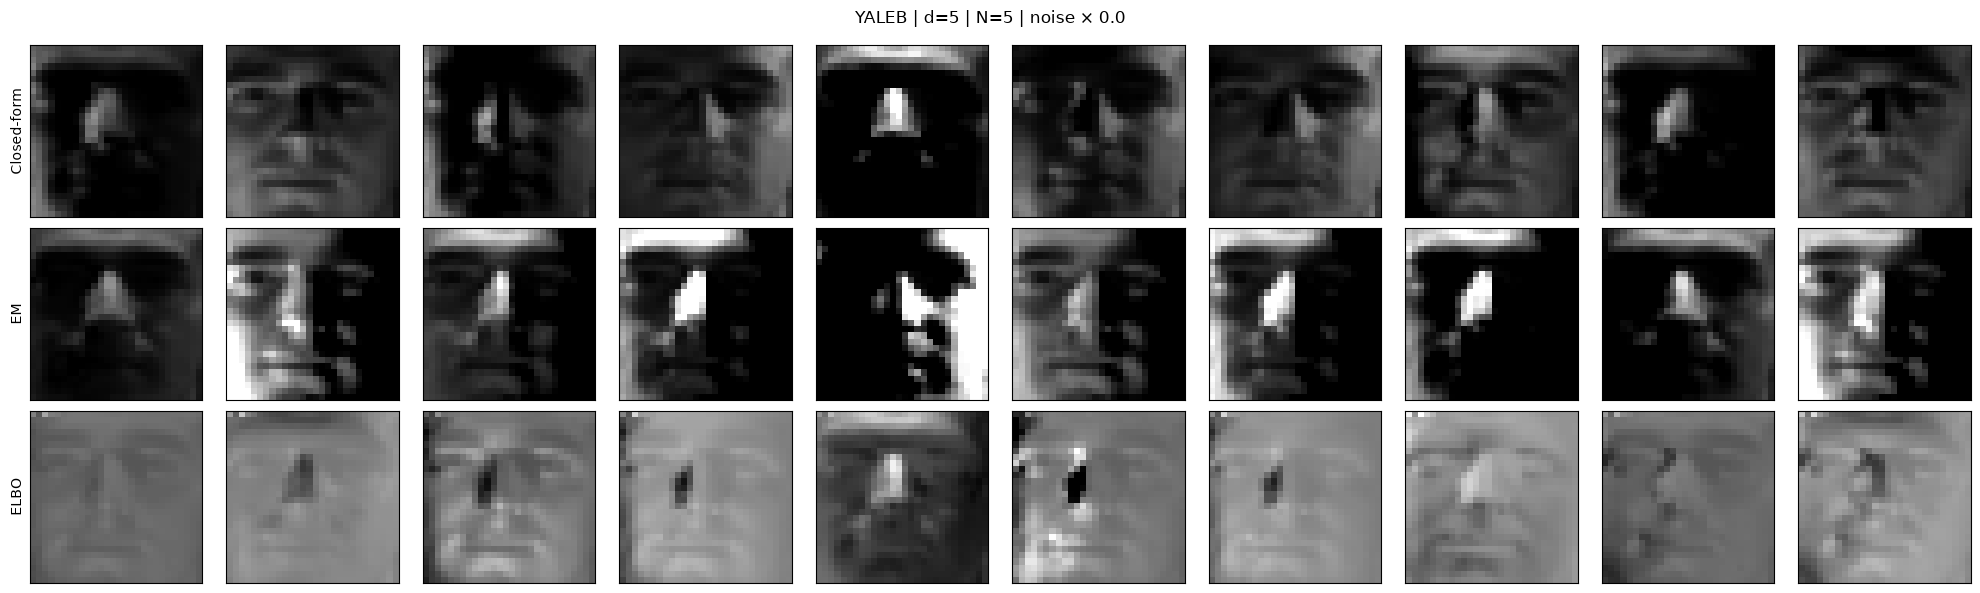

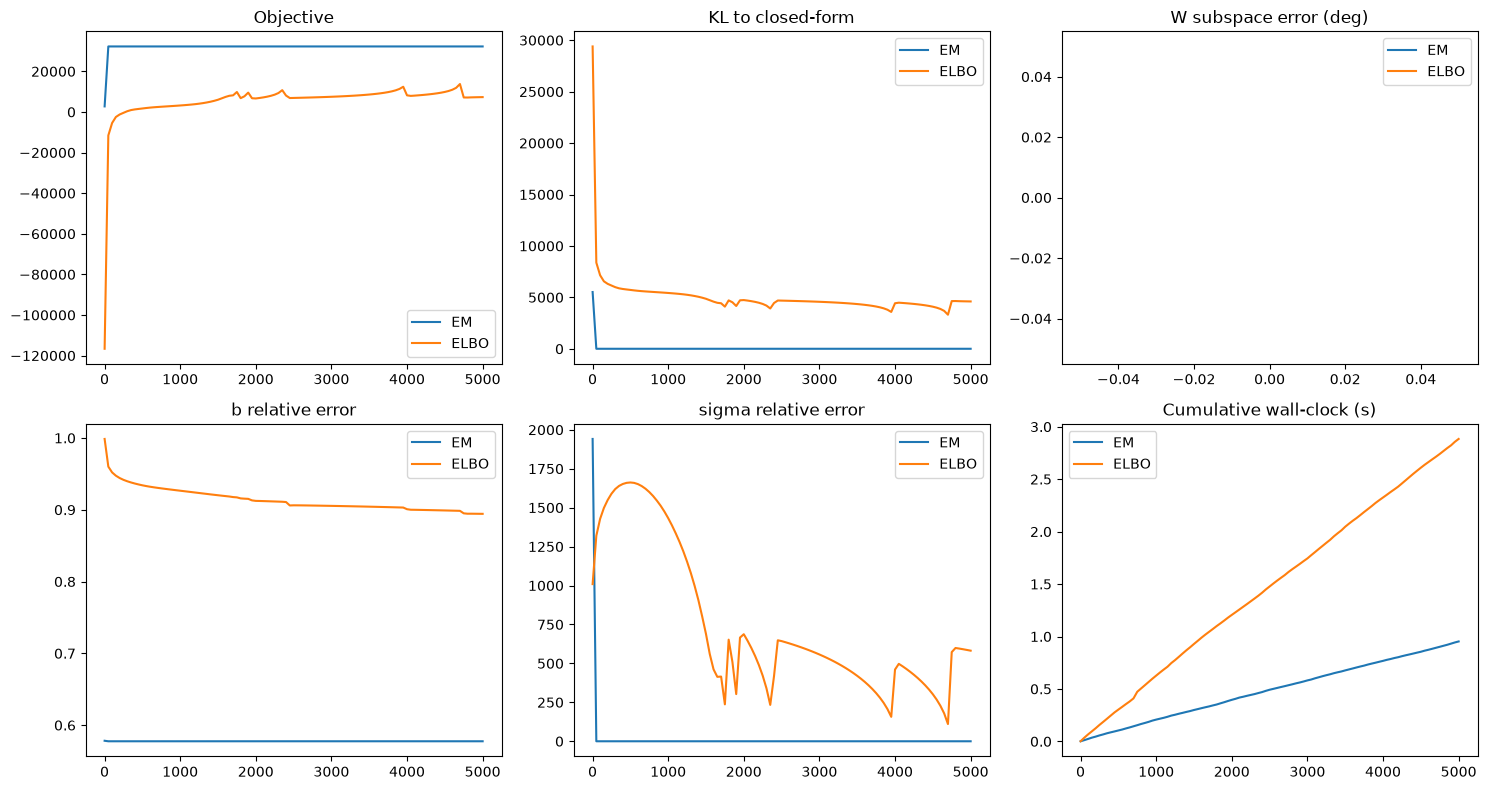


YALEB | N=3, D=784, d=5
Class counts: {37: 3}
Noise floor active: reference is a constrained fit, not a finite unconstrained MLE.
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: 19431.844523; per sample: 6477.281508
EM           log-likelihood: 19425.153474; per sample: 6475.051158
ELBO         log-likelihood: 4350.033634; per sample: 1450.011211
Reference exact-posterior ELBO: 19431.844523; LL gap: 3.18e-07
Learned encoder ELBO: 4350.026257


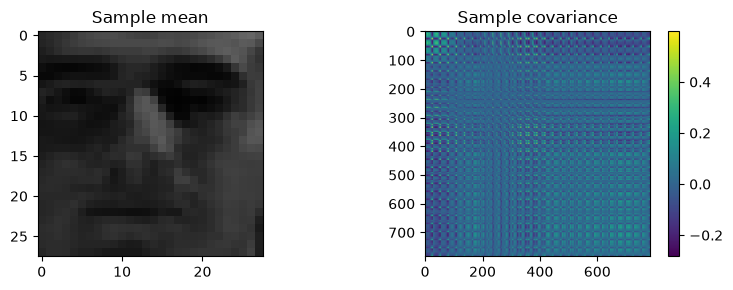

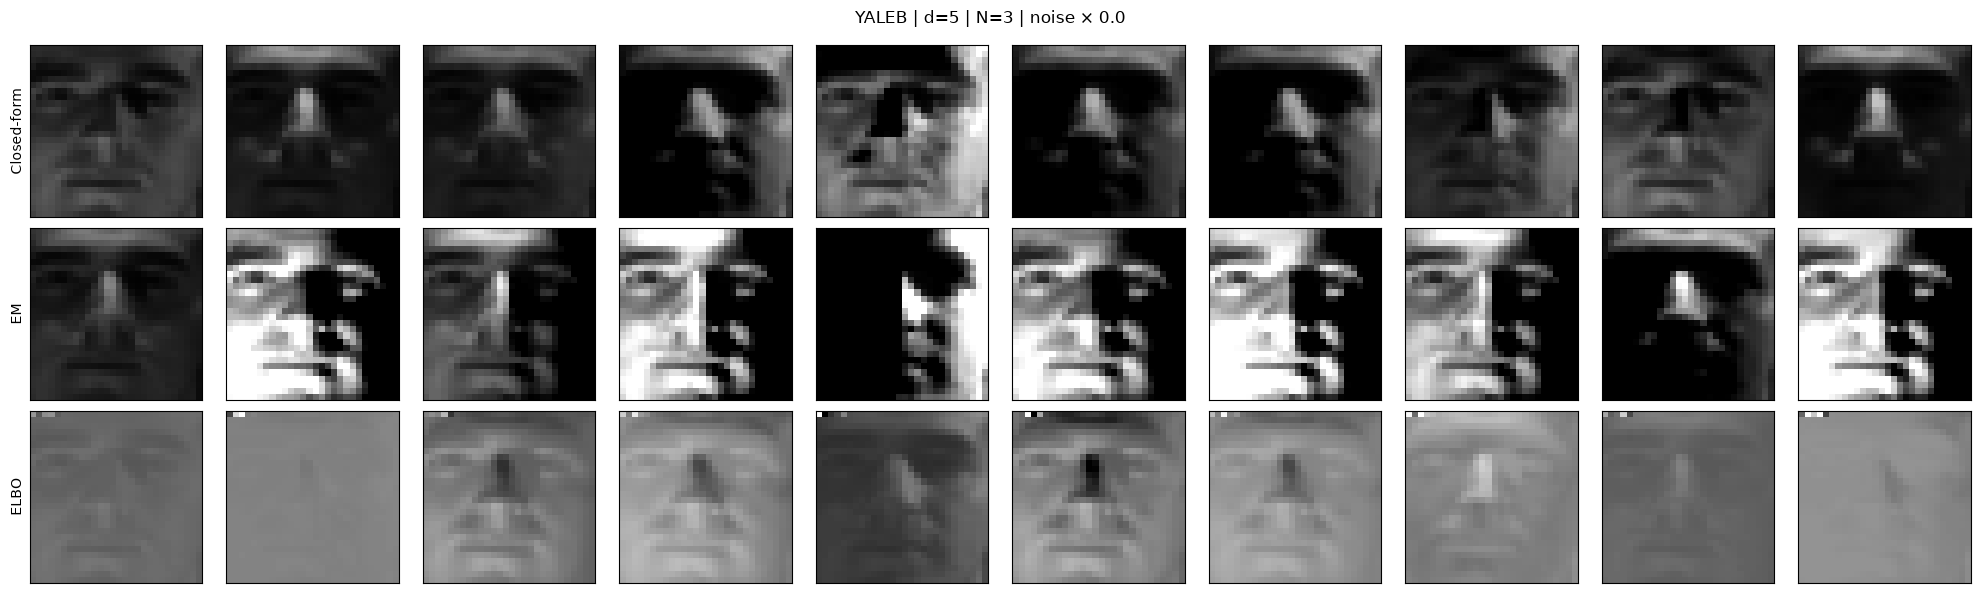

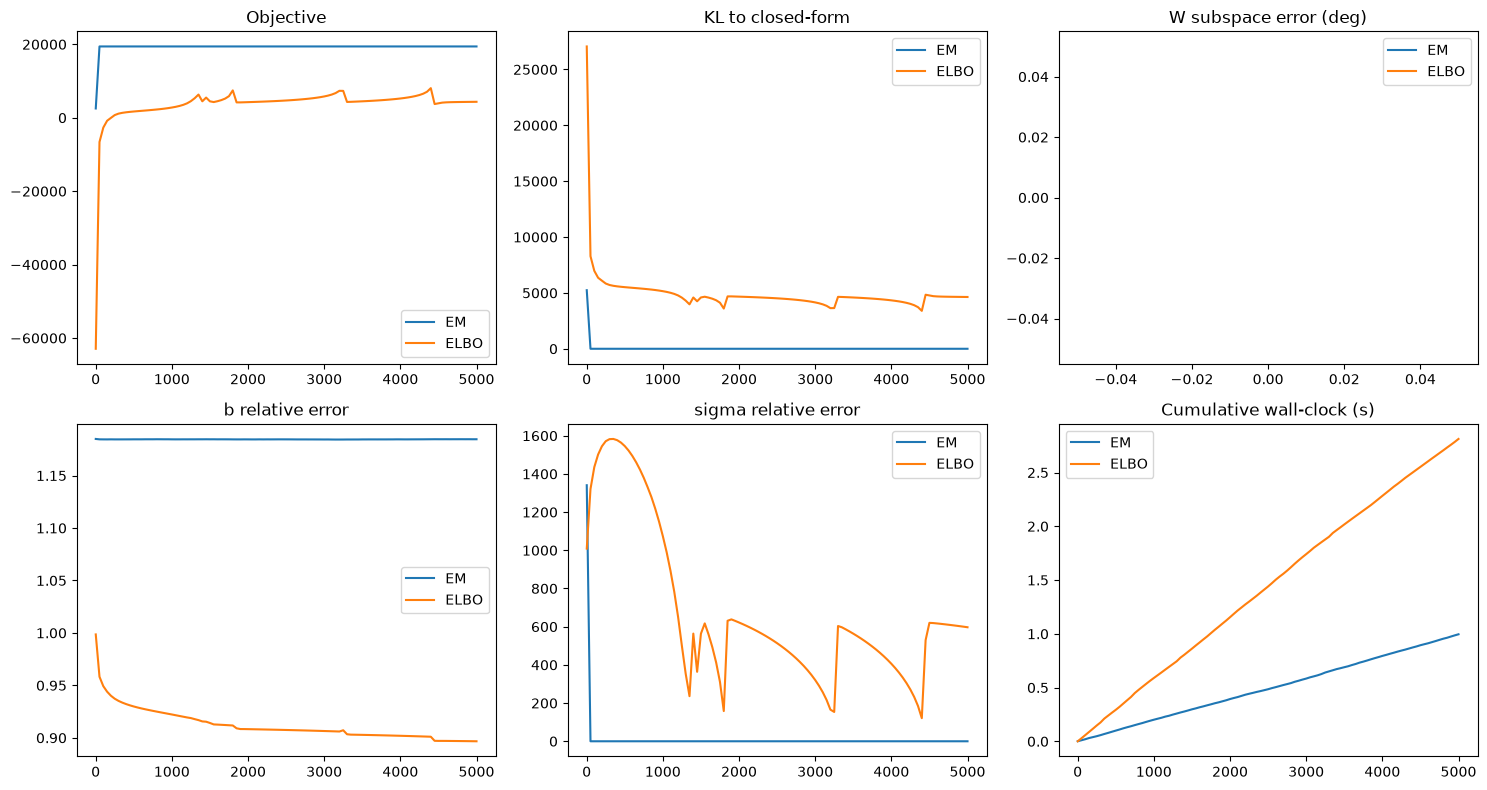


MNIST | N=150, D=784, d=20
Class counts: {0: 150}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: 1824.920940; per sample: 12.166140
EM           log-likelihood: 1824.920940; per sample: 12.166140
ELBO         log-likelihood: -1865.866395; per sample: -12.439109
Reference exact-posterior ELBO: 1824.920940; LL gap: 1.46e-11
Learned encoder ELBO: -4351.819009


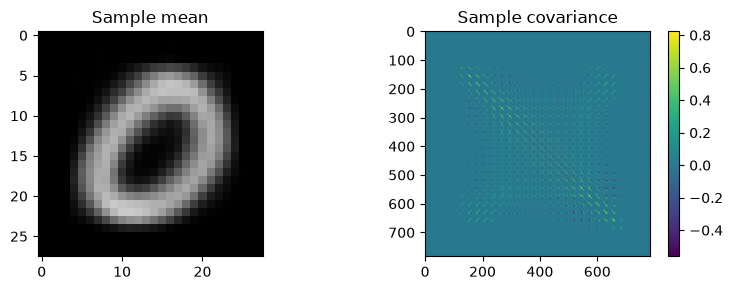

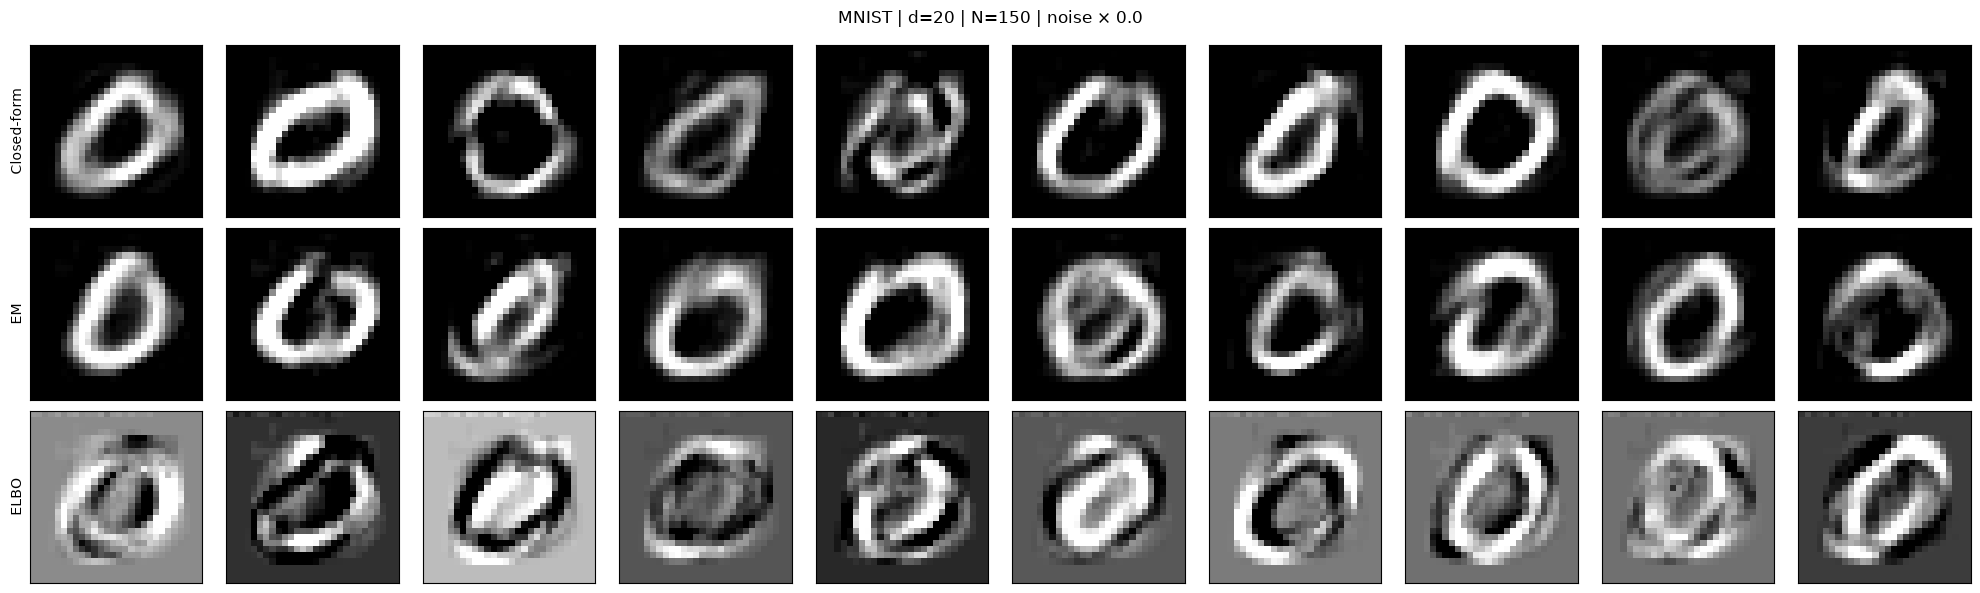

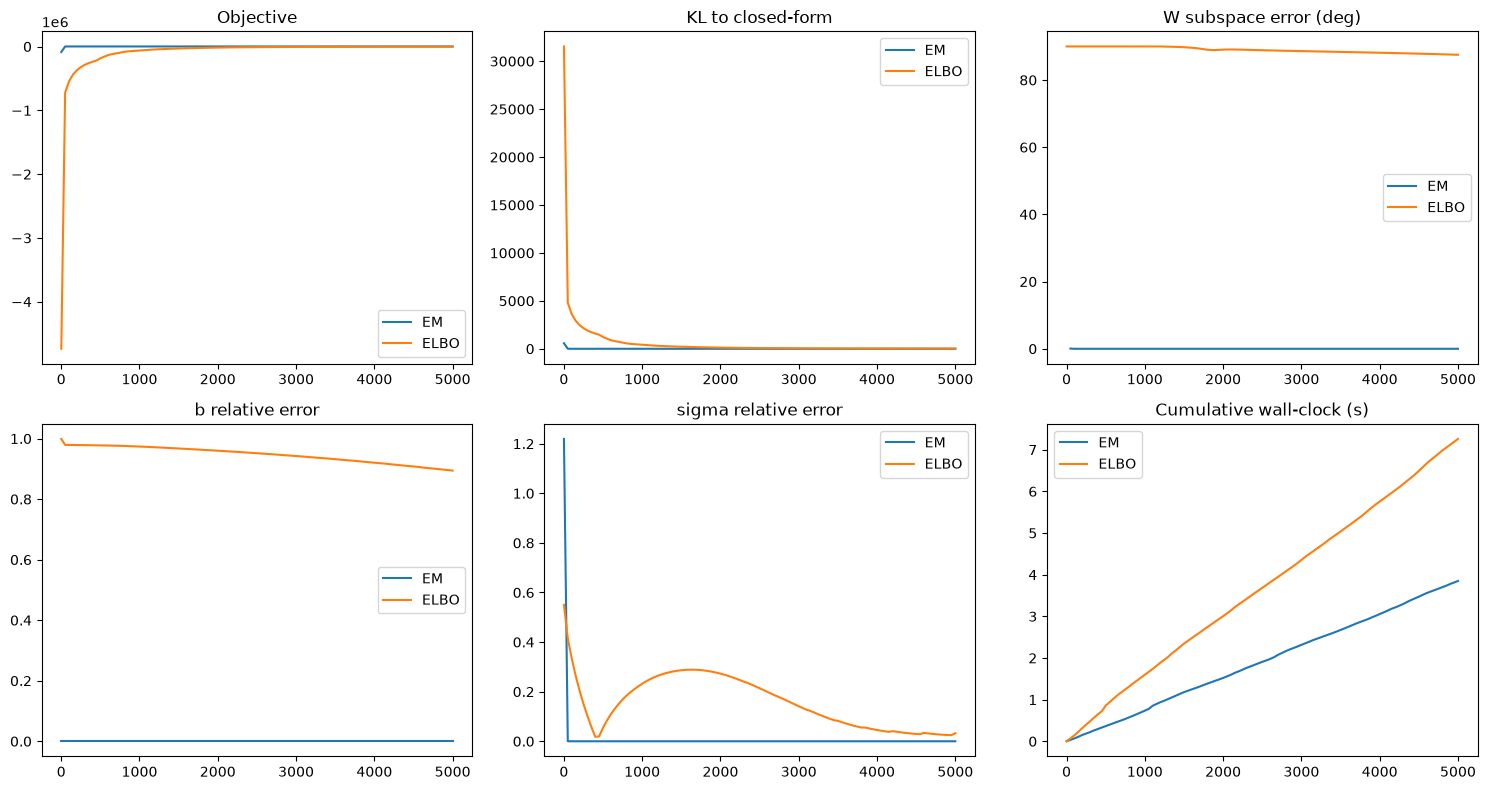


MNIST | N=20, D=784, d=20
Class counts: {0: 20}
Noise floor active: reference is a constrained fit, not a finite unconstrained MLE.
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: 125957.891361; per sample: 6297.894568
EM           log-likelihood: 123437.613856; per sample: 6171.880693
ELBO         log-likelihood: 28165.170130; per sample: 1408.258506
Reference exact-posterior ELBO: 125957.891381; LL gap: -2.03e-05
Learned encoder ELBO: 28165.148847


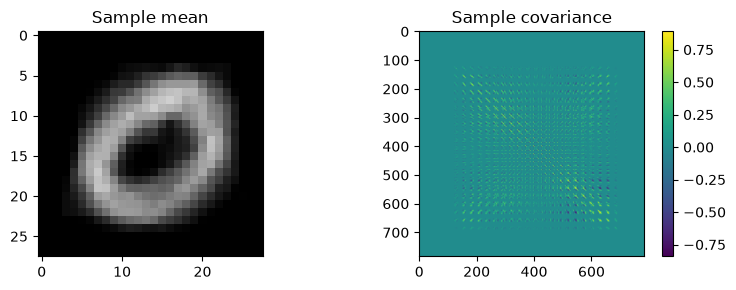

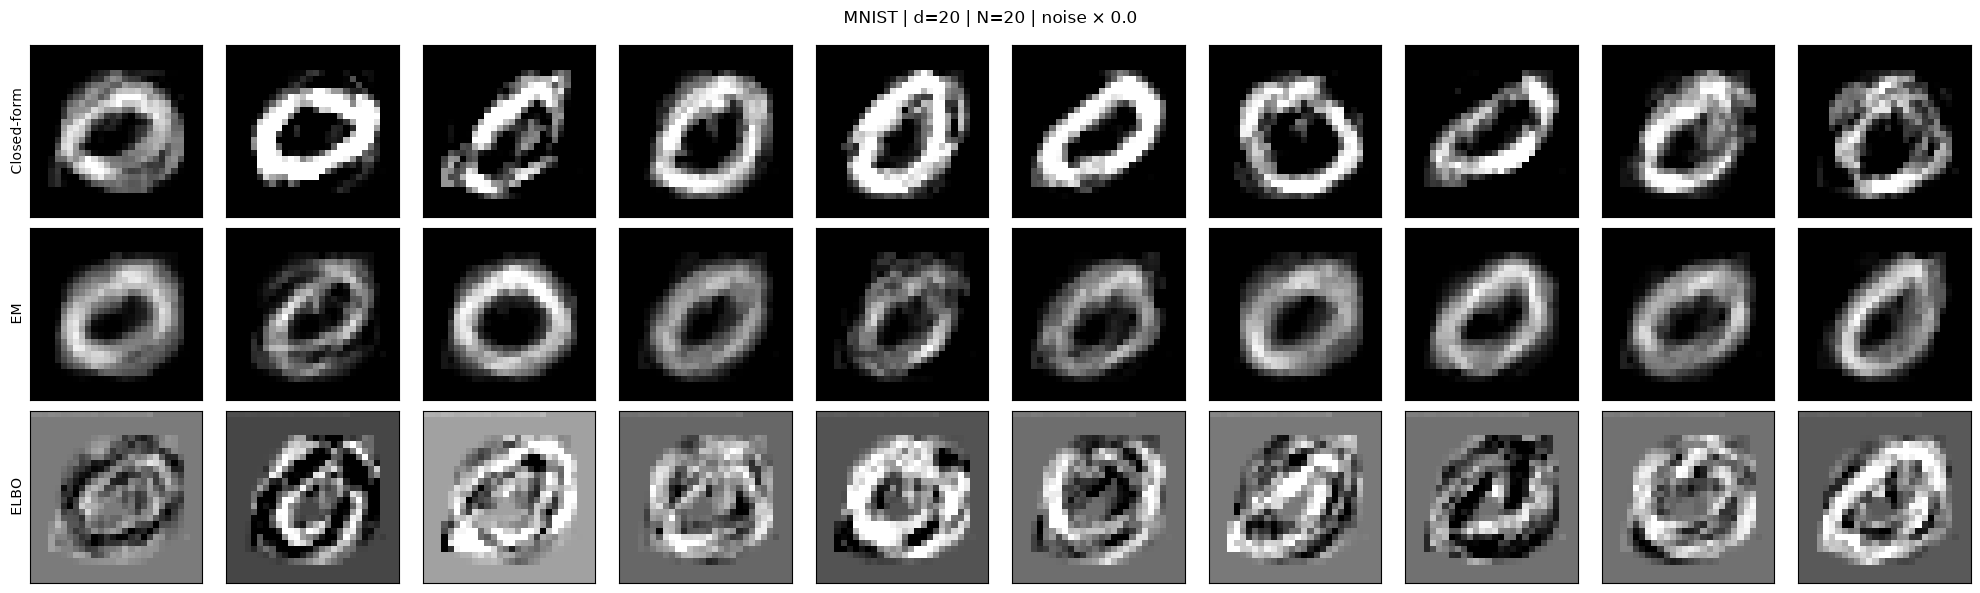

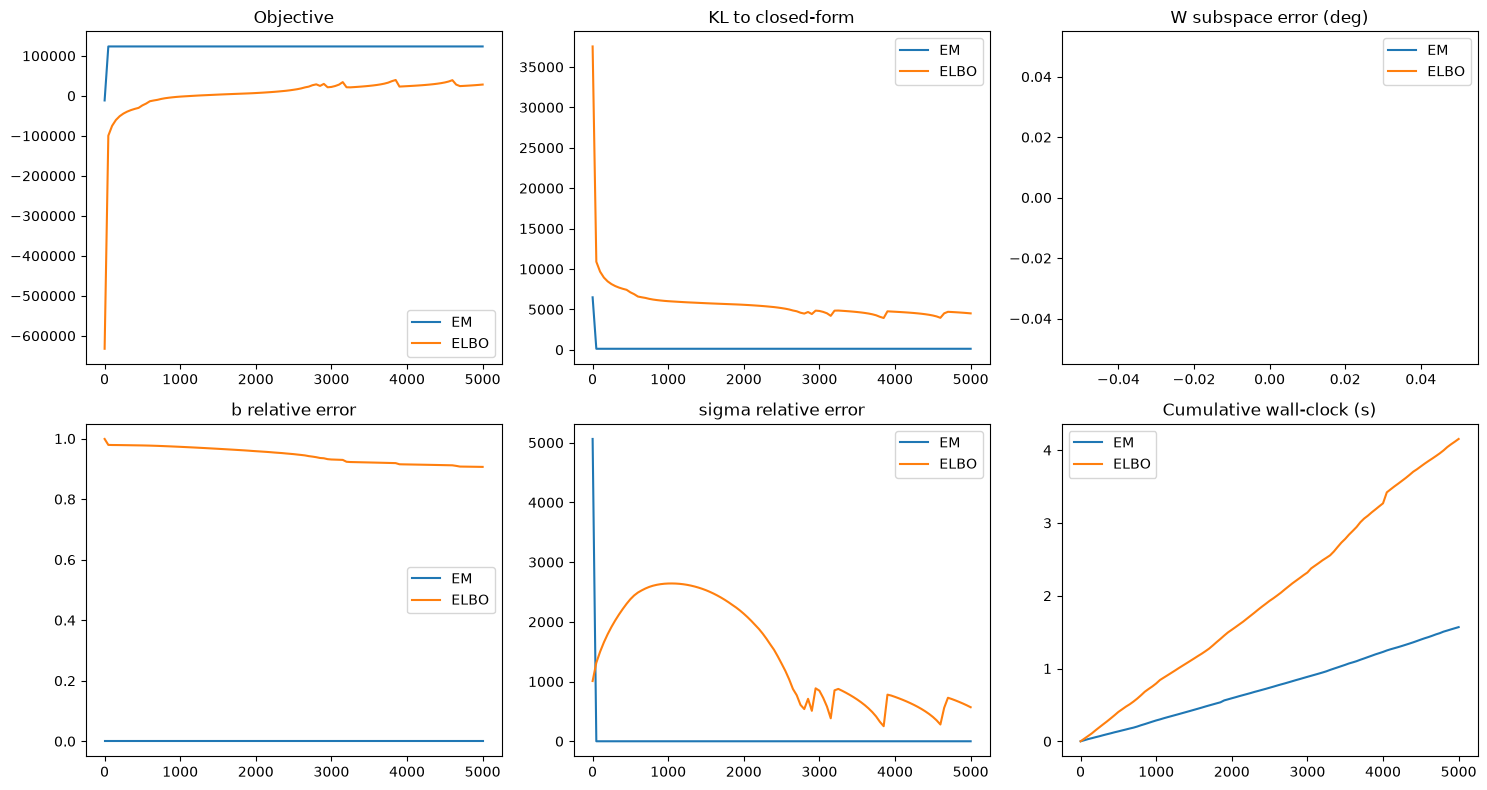


MNIST | N=5, D=784, d=20
Class counts: {0: 5}
Noise floor active: reference is a constrained fit, not a finite unconstrained MLE.
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: 32275.270465; per sample: 6455.054093
EM           log-likelihood: 31822.384407; per sample: 6364.476881
ELBO         log-likelihood: 7550.927370; per sample: 1510.185474
Reference exact-posterior ELBO: 32275.270469; LL gap: -4.15e-06
Learned encoder ELBO: 7550.839527


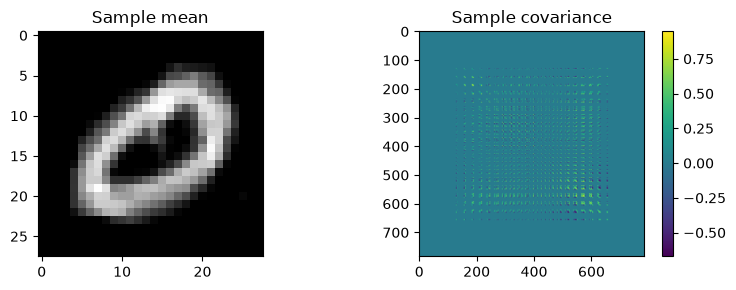

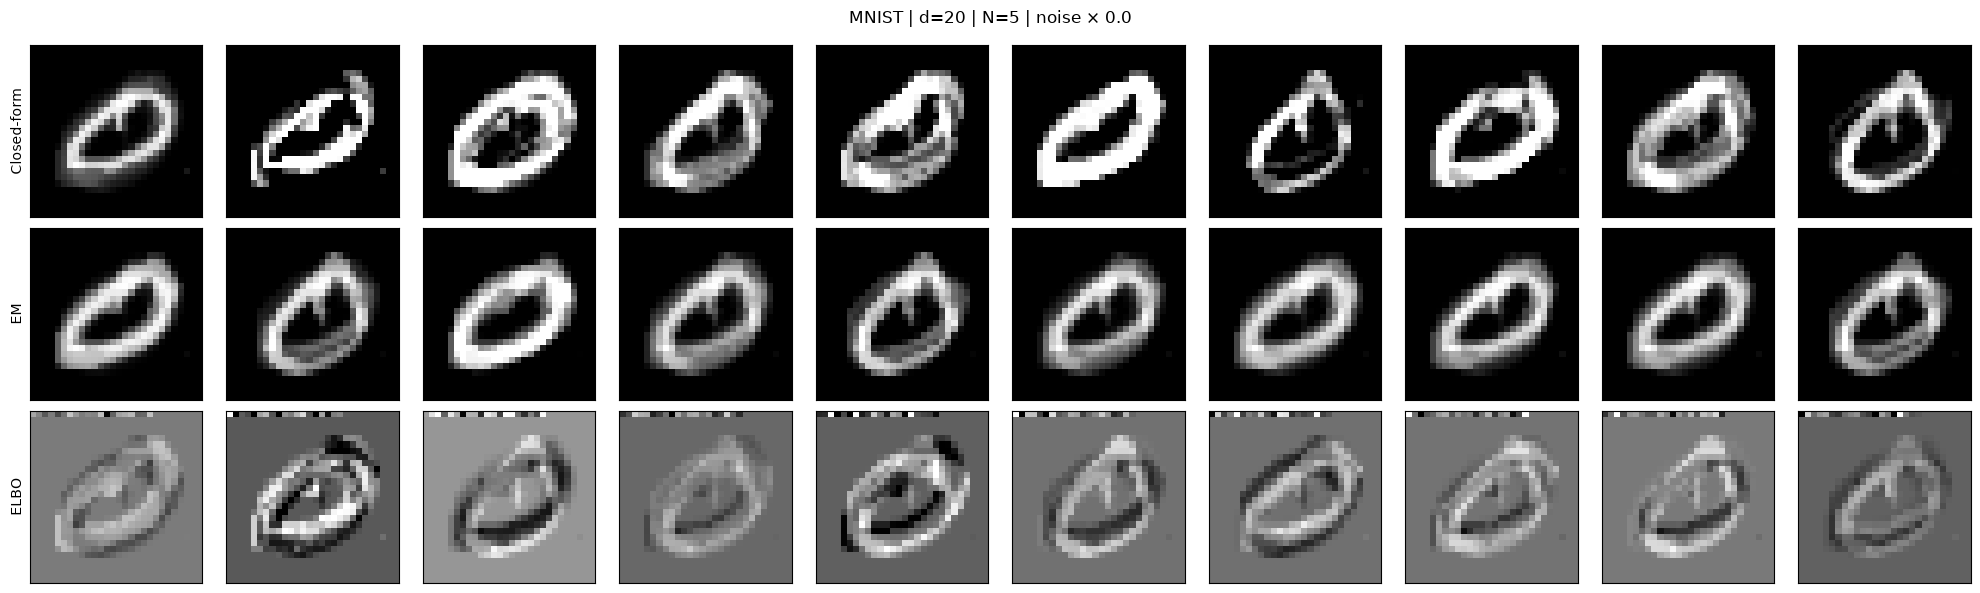

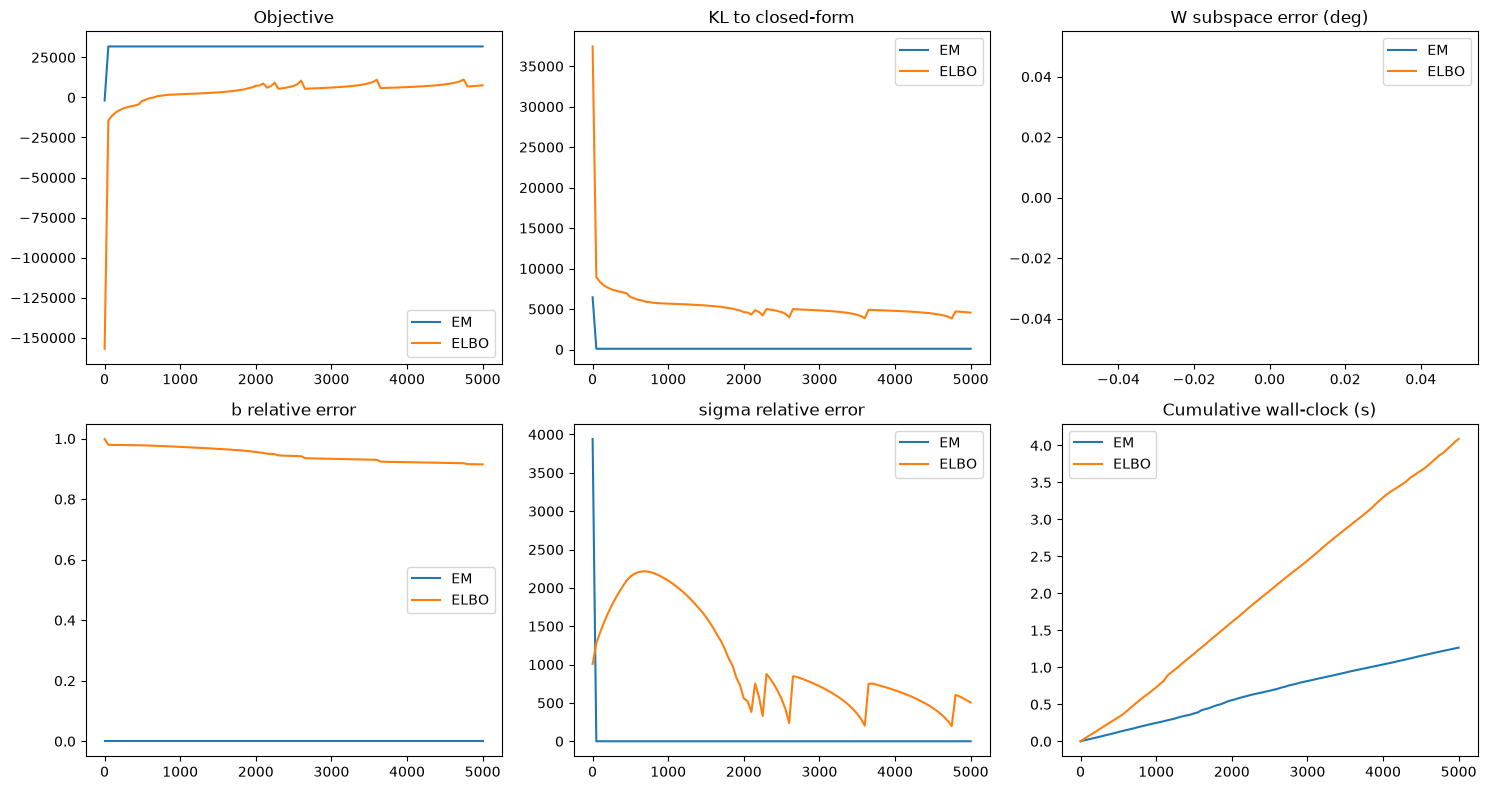

In [7]:
results_g = {}
for N in [50, 5, 3]:
    results_g[("YALEB", N)] = run_experiment({
        **CONFIG,
        "dataset": "YALEB",
        "classes": [37],
        "latent_dimension": 5,
        "limit_n_samples": N,
    })
for N in [150, 20, 5]:
    results_g[("MNIST", N)] = run_experiment({
        **CONFIG,
        "latent_dimension": 20,
        "limit_n_samples": N,
    })

## Part (h)
Suppose now we move into a two/three-class regime, by adding classes to the *CLASSES* list. What do you observe about the sample mean and covariance? Based on the data samples we have, do the images generated make sense? 


MNIST | N=1000, D=784, d=2
Class counts: {0: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -443425.373633; per sample: -443.425374
EM           log-likelihood: -443425.373633; per sample: -443.425374
ELBO         log-likelihood: -497648.845451; per sample: -497.648845
Reference exact-posterior ELBO: -443425.373633; LL gap: 5.82e-11
Learned encoder ELBO: -497648.915549


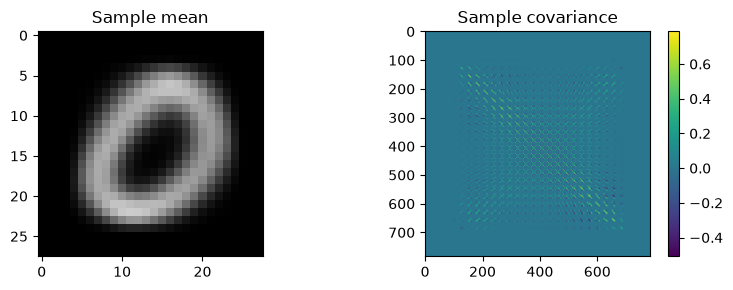

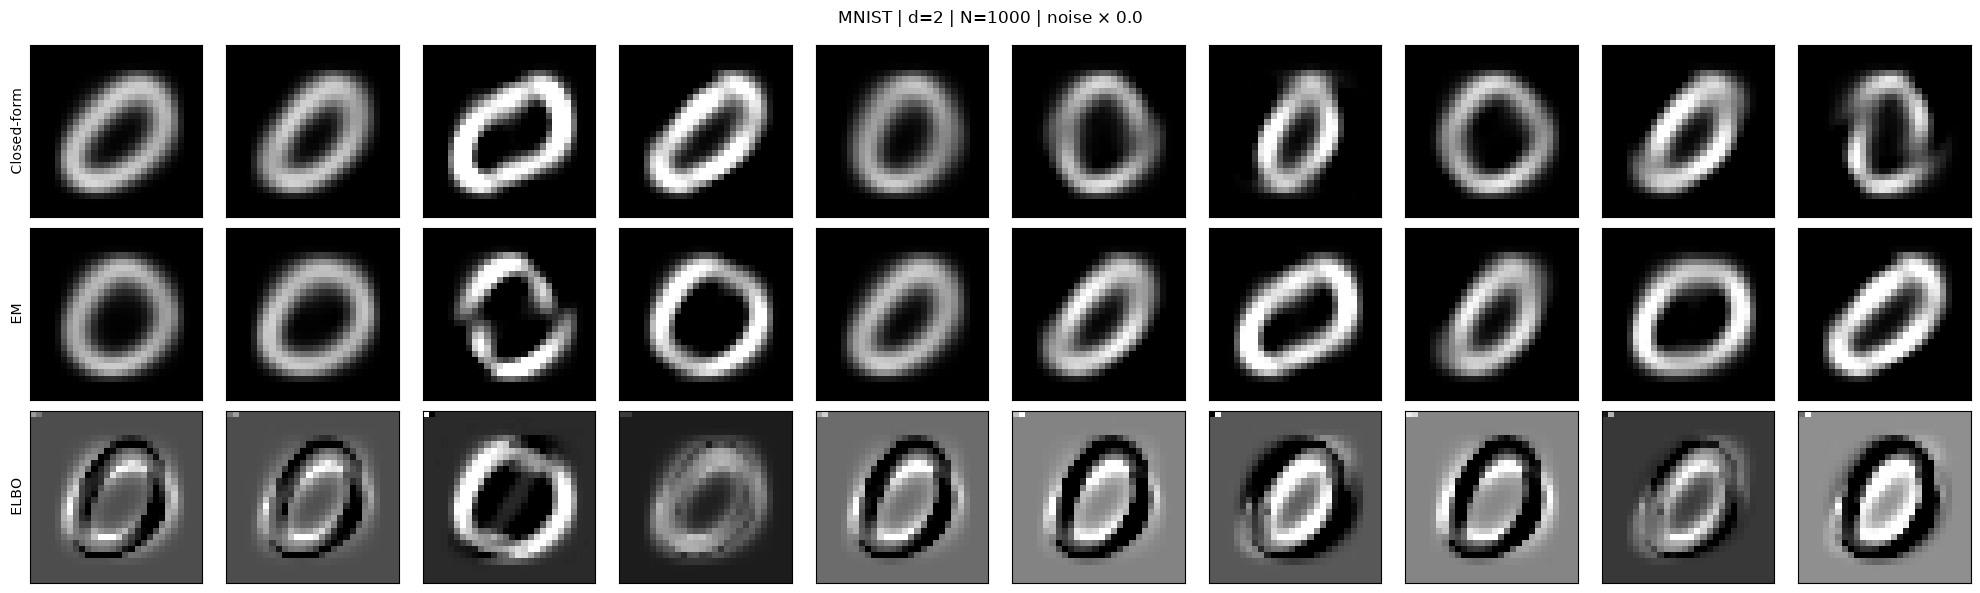

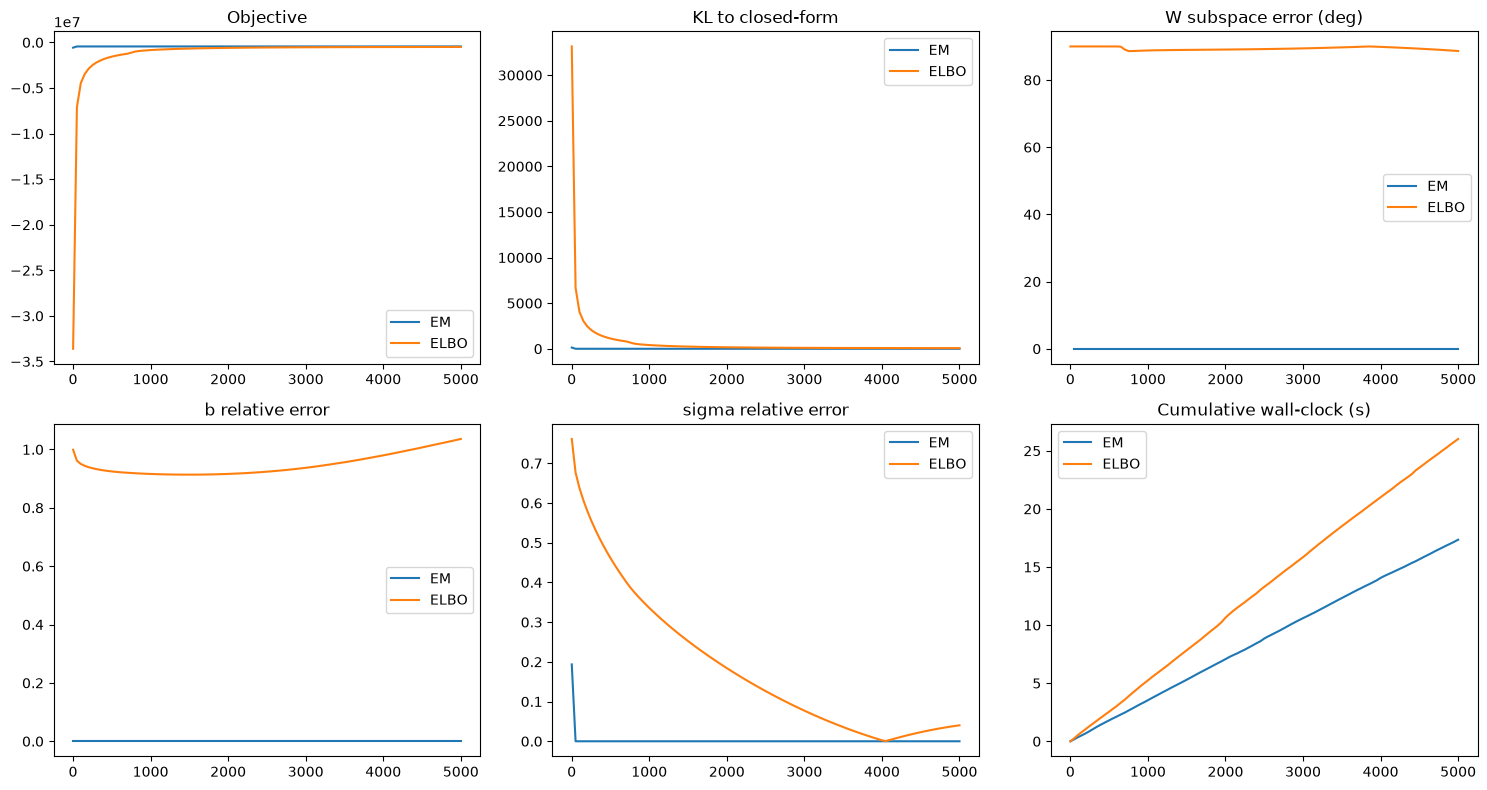


MNIST | N=2000, D=784, d=2
Class counts: {0: 1000, 1: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -771597.954557; per sample: -385.798977
EM           log-likelihood: -771597.954557; per sample: -385.798977
ELBO         log-likelihood: -860109.110650; per sample: -430.054555
Reference exact-posterior ELBO: -771597.954557; LL gap: 3.49e-10
Learned encoder ELBO: -860110.164183


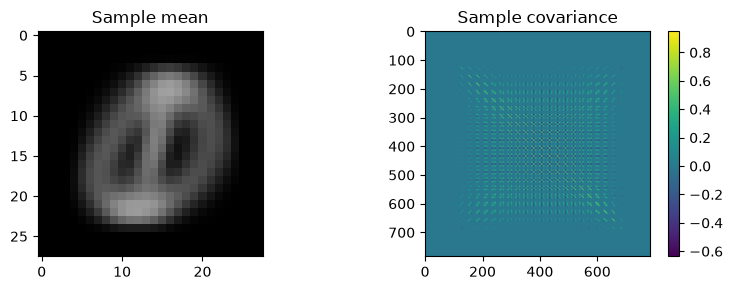

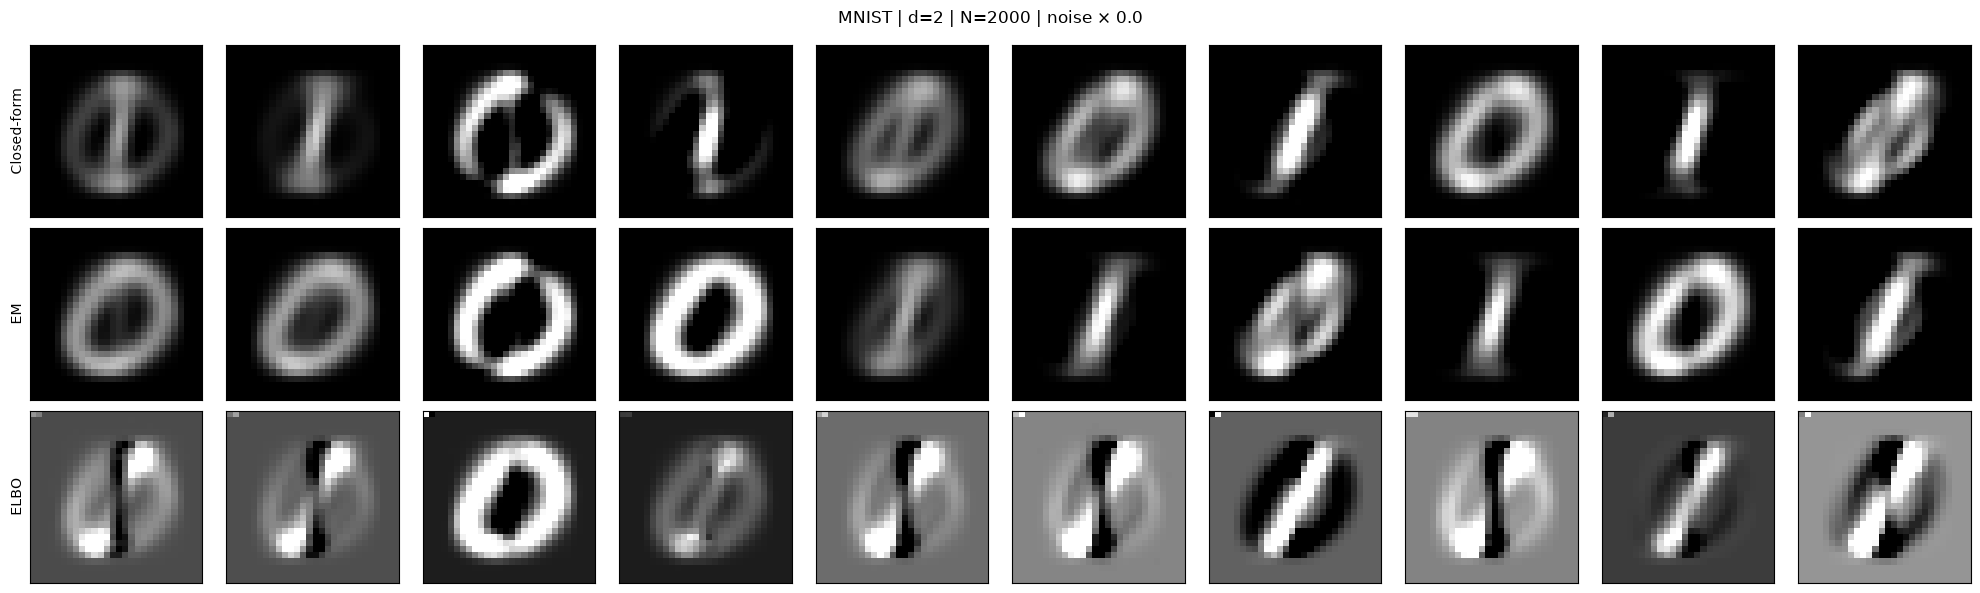

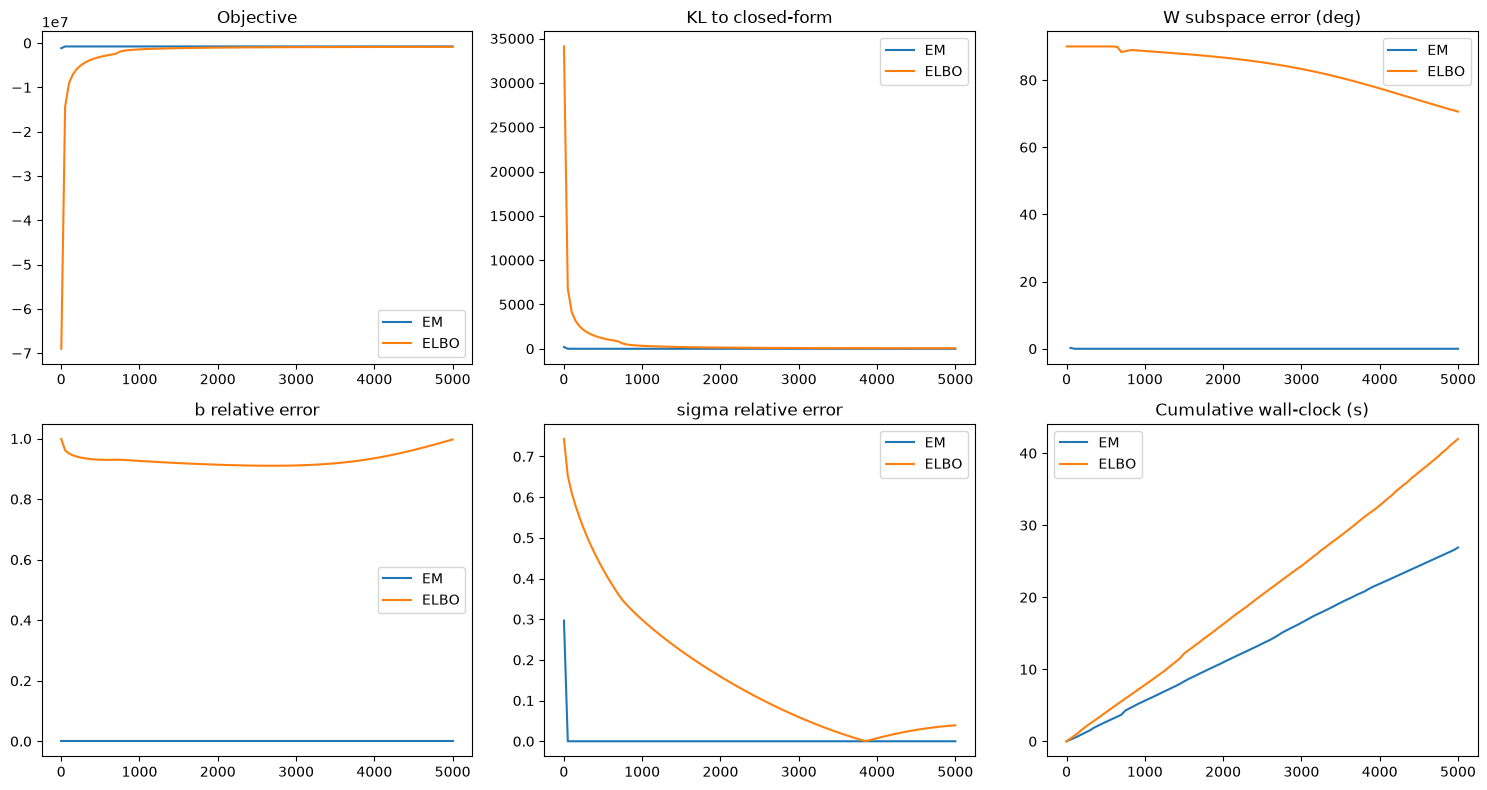


MNIST | N=3000, D=784, d=2
Class counts: {0: 1000, 1: 1000, 2: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -1409459.578085; per sample: -469.819859
EM           log-likelihood: -1409459.578085; per sample: -469.819859
ELBO         log-likelihood: -1519274.827037; per sample: -506.424942
Reference exact-posterior ELBO: -1409459.578085; LL gap: 4.66e-10
Learned encoder ELBO: -1519275.376202


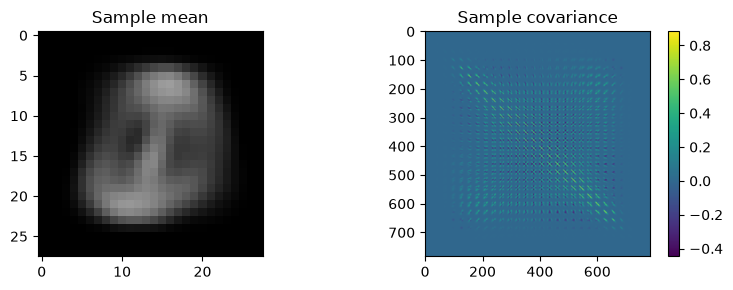

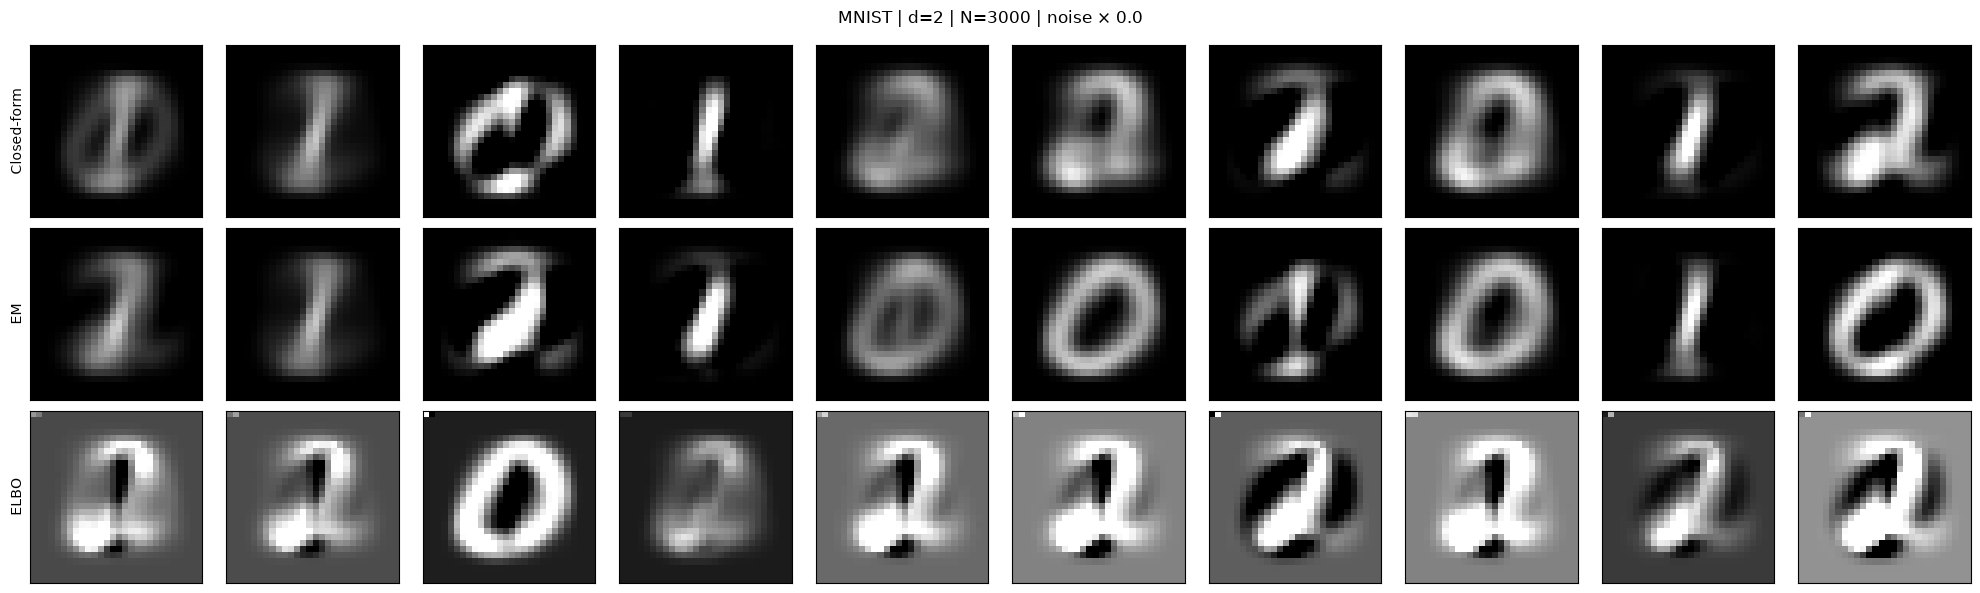

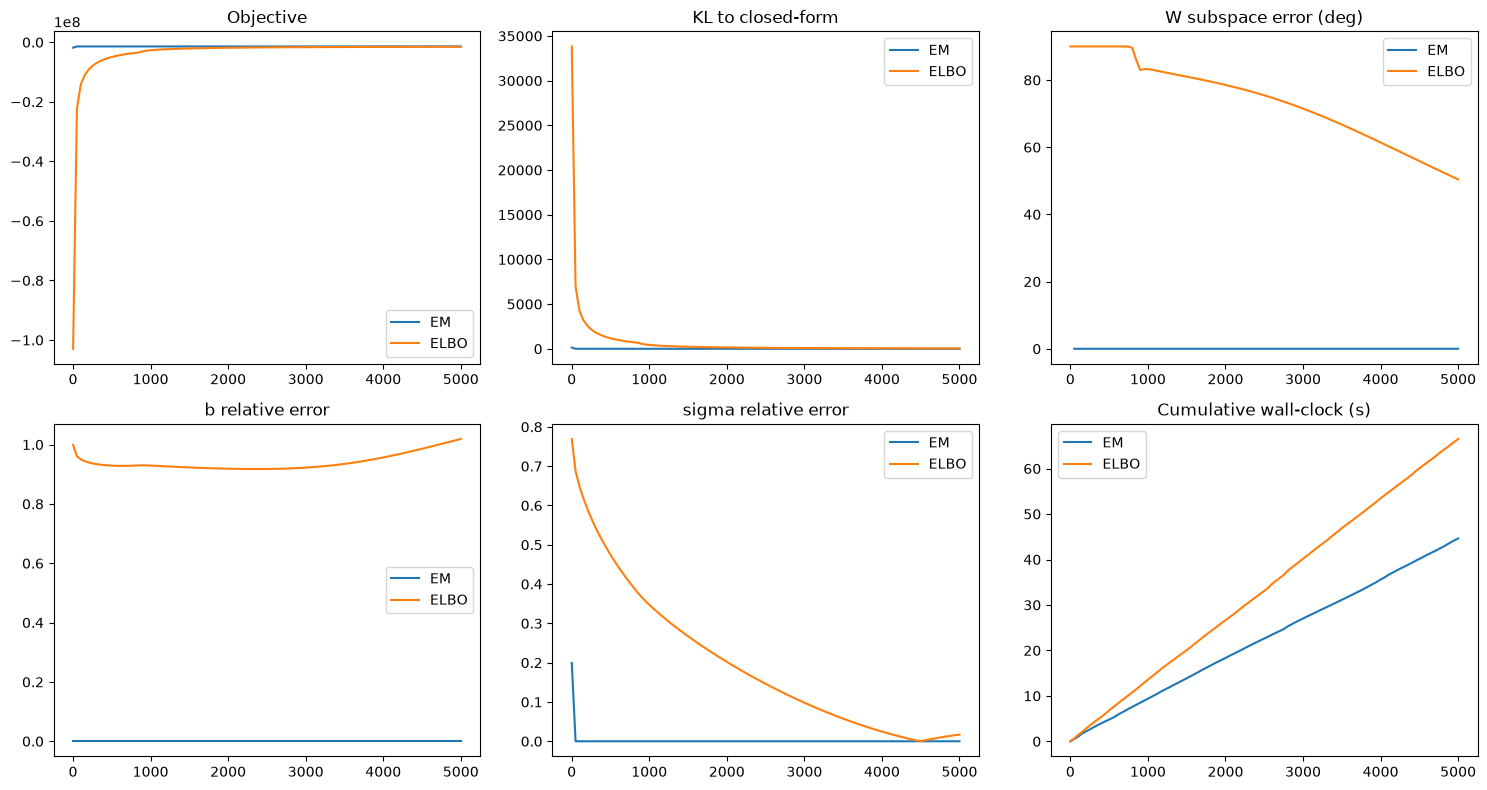


MNIST | N=10000, D=784, d=2
Class counts: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -5339951.624098; per sample: -533.995162
EM           log-likelihood: -5339951.624098; per sample: -533.995162
ELBO         log-likelihood: -5638530.185534; per sample: -563.853019
Reference exact-posterior ELBO: -5339951.624098; LL gap: 9.31e-10
Learned encoder ELBO: -5638543.417362


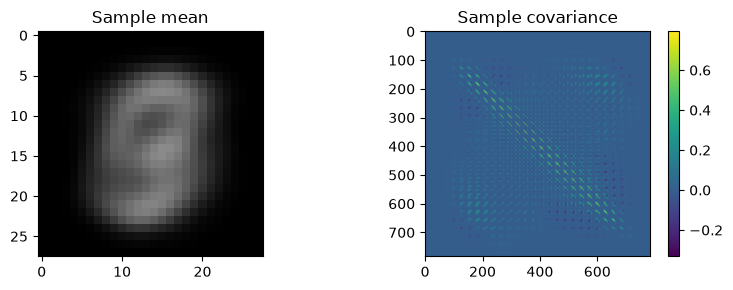

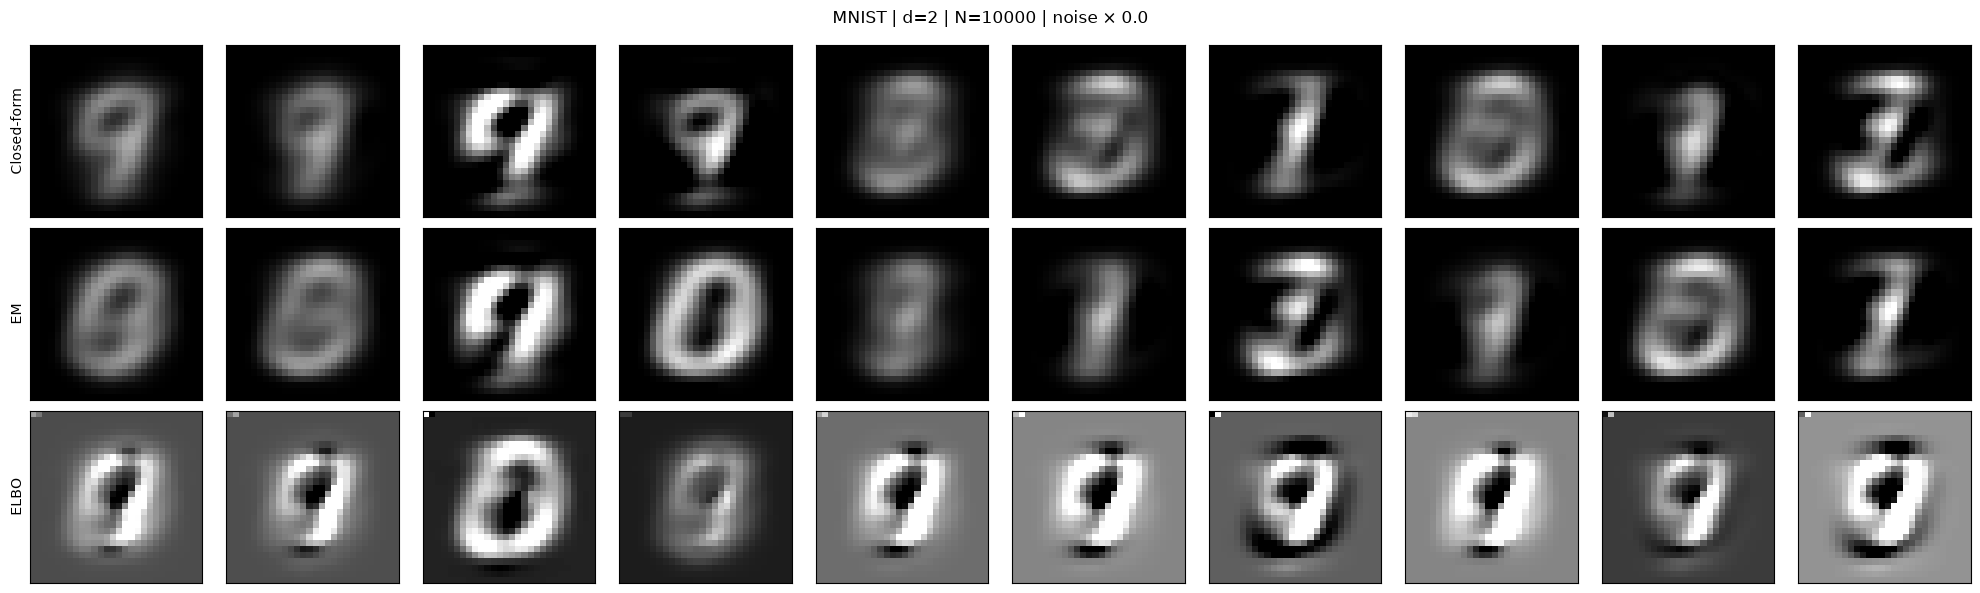

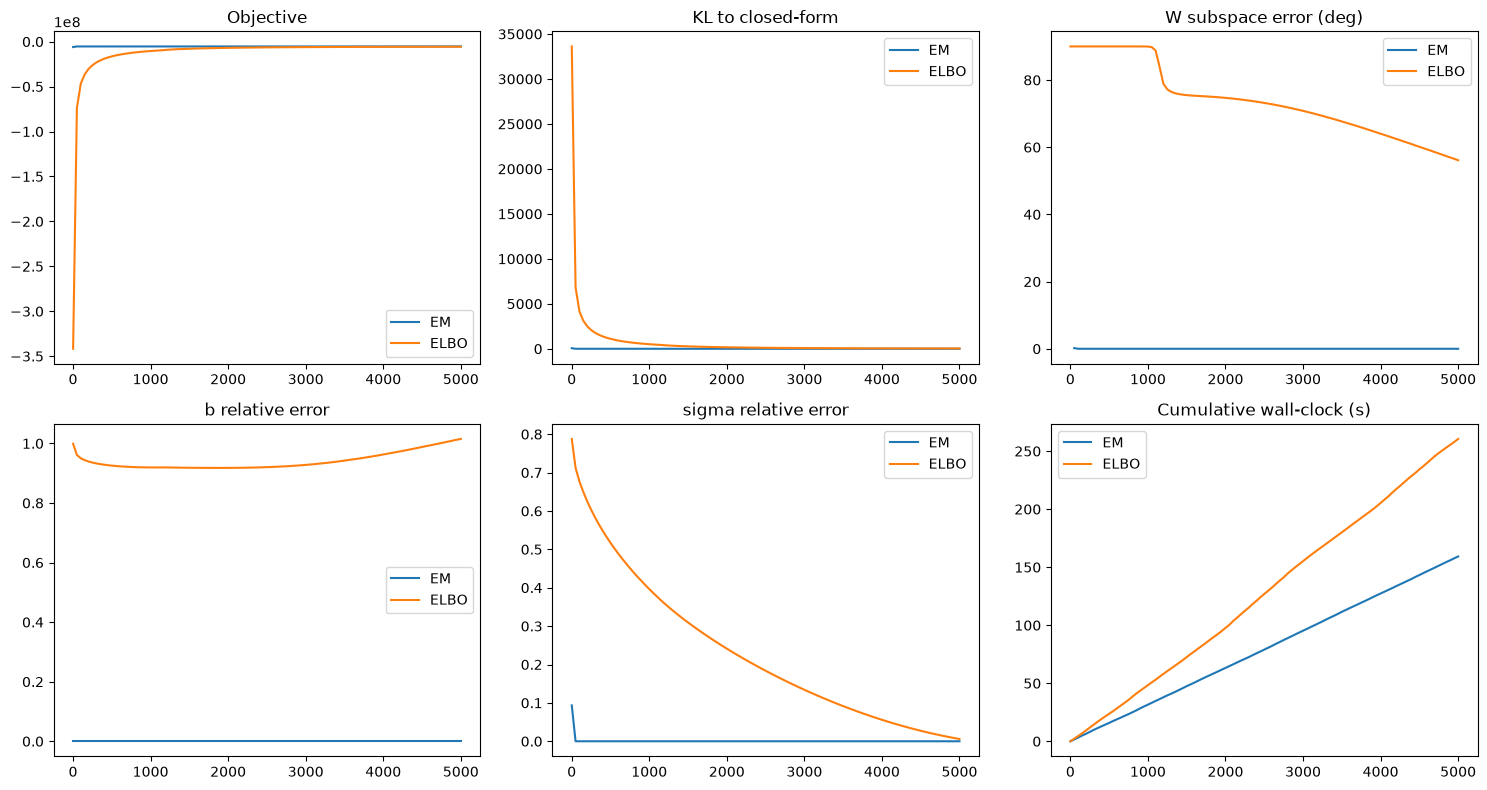

In [6]:
results_h = {}
for classes in [[0], [0, 1], [0, 1, 2], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]:
    results_h[tuple(classes)] = run_experiment({
        **CONFIG,
        "classes": classes,
        "samples_per_class": 1000,
        "limit_n_samples": None,
    })


MNIST | N=1000, D=784, d=2
Class counts: {0: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -443425.373633; per sample: -443.425374
EM           log-likelihood: -443425.373633; per sample: -443.425374
ELBO         log-likelihood: -443902.043066; per sample: -443.902043
Reference exact-posterior ELBO: -443425.373633; LL gap: -5.82e-11
Learned encoder ELBO: -445816.432045


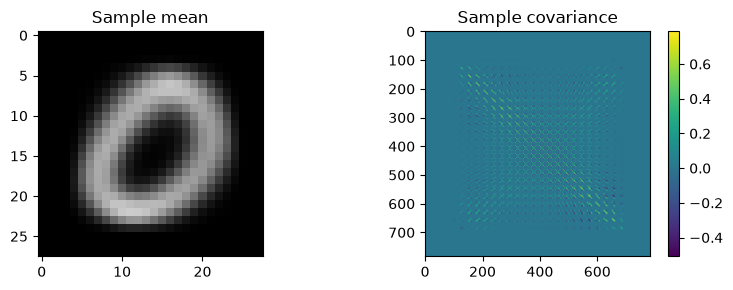

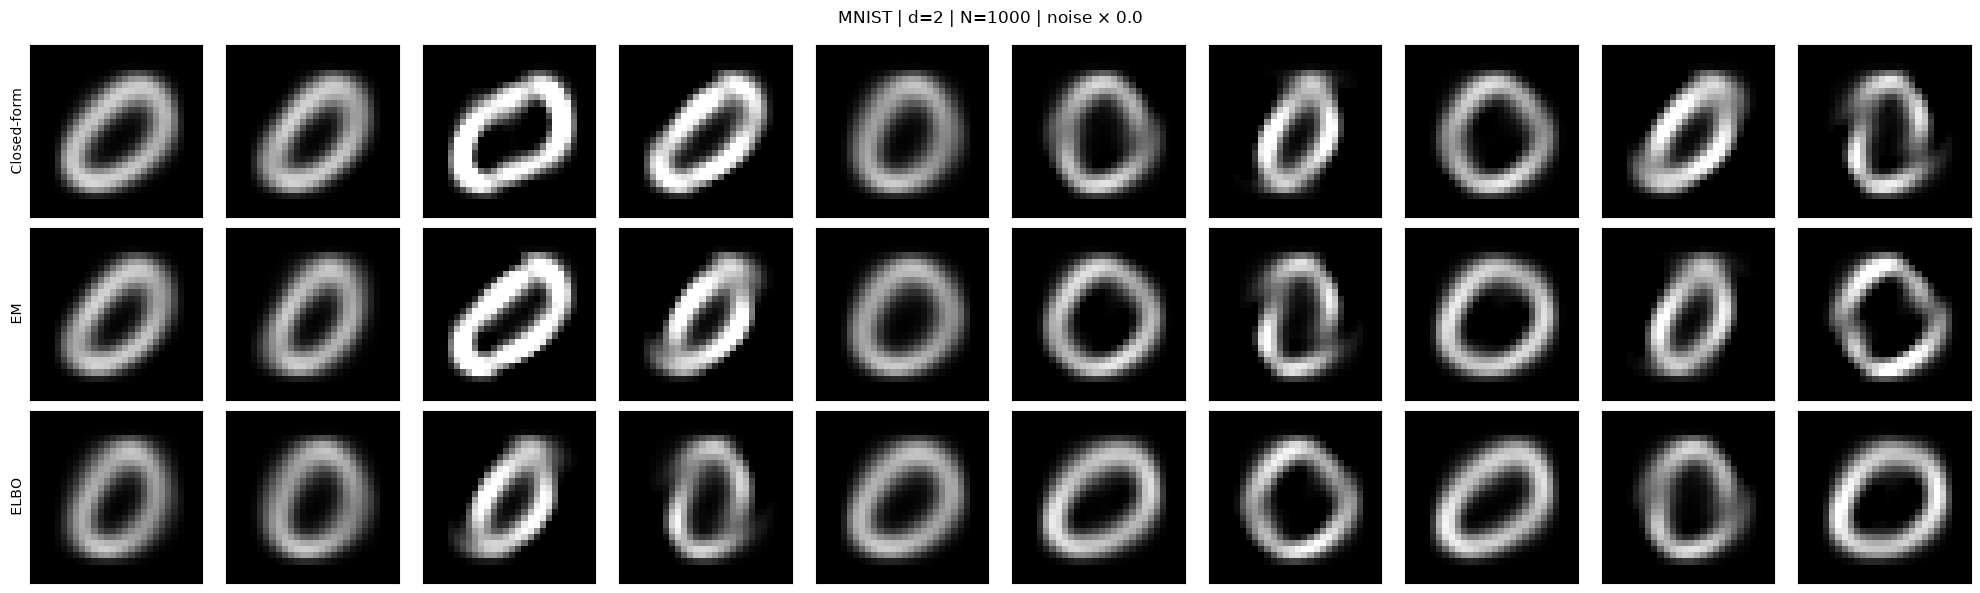

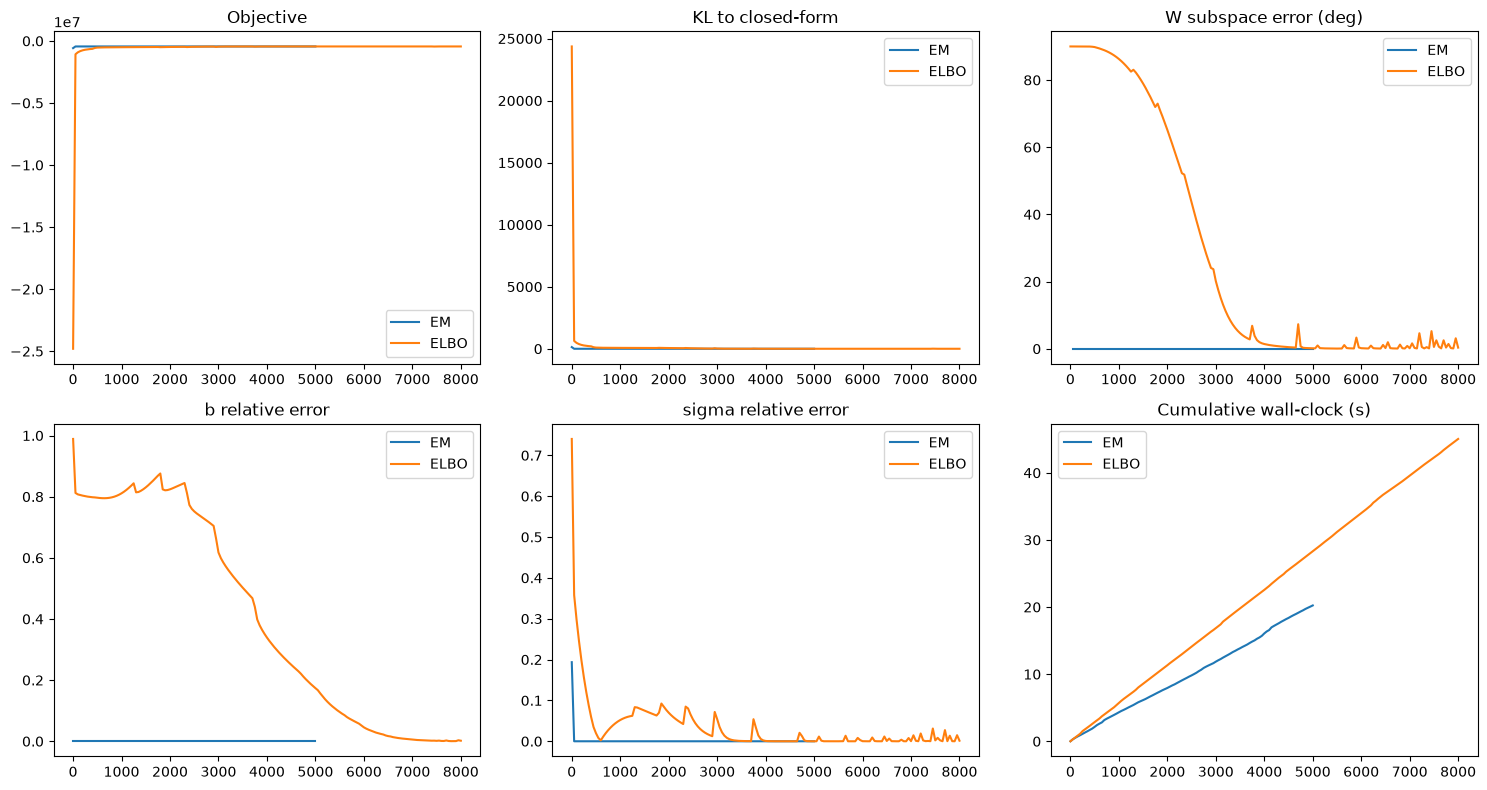

{'config': {'dataset': 'MNIST',
  'root': '../../data',
  'classes': [0],
  'limit_n_samples': 1000,
  'samples_per_class': None,
  'latent_dimension': 2,
  'noise_level': 0.0,
  'n_generated': 10,
  'em_iterations': 5000,
  'elbo_iterations': 8000,
  'learning_rate': 0.01,
  'seed': 0,
  'sigma_min': 0.0001,
  'metric_every': 50,
  'show_plots': True,
  'plot_start': 500},
 'X': tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]], dtype=torch.float64),
 'y': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
# Better Gradient Ascent

_ = run_experiment({**CONFIG, "learning_rate": 0.01, "elbo_iterations": 5000,})


MNIST | N=1000, D=784, d=5
Class counts: {0: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -330410.699839; per sample: -330.410700
EM           log-likelihood: -330410.699839; per sample: -330.410700
ELBO         log-likelihood: -333747.979143; per sample: -333.747979
Reference exact-posterior ELBO: -330410.699839; LL gap: 1.16e-10
Learned encoder ELBO: -333887.851053


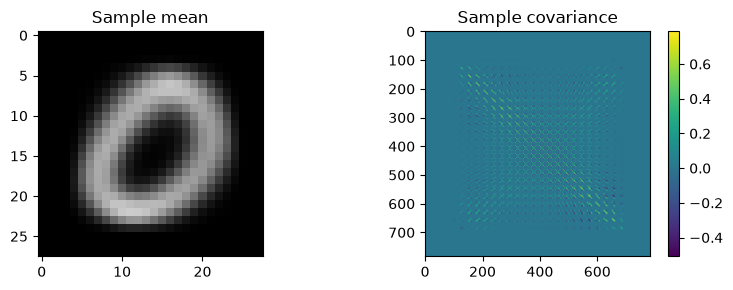

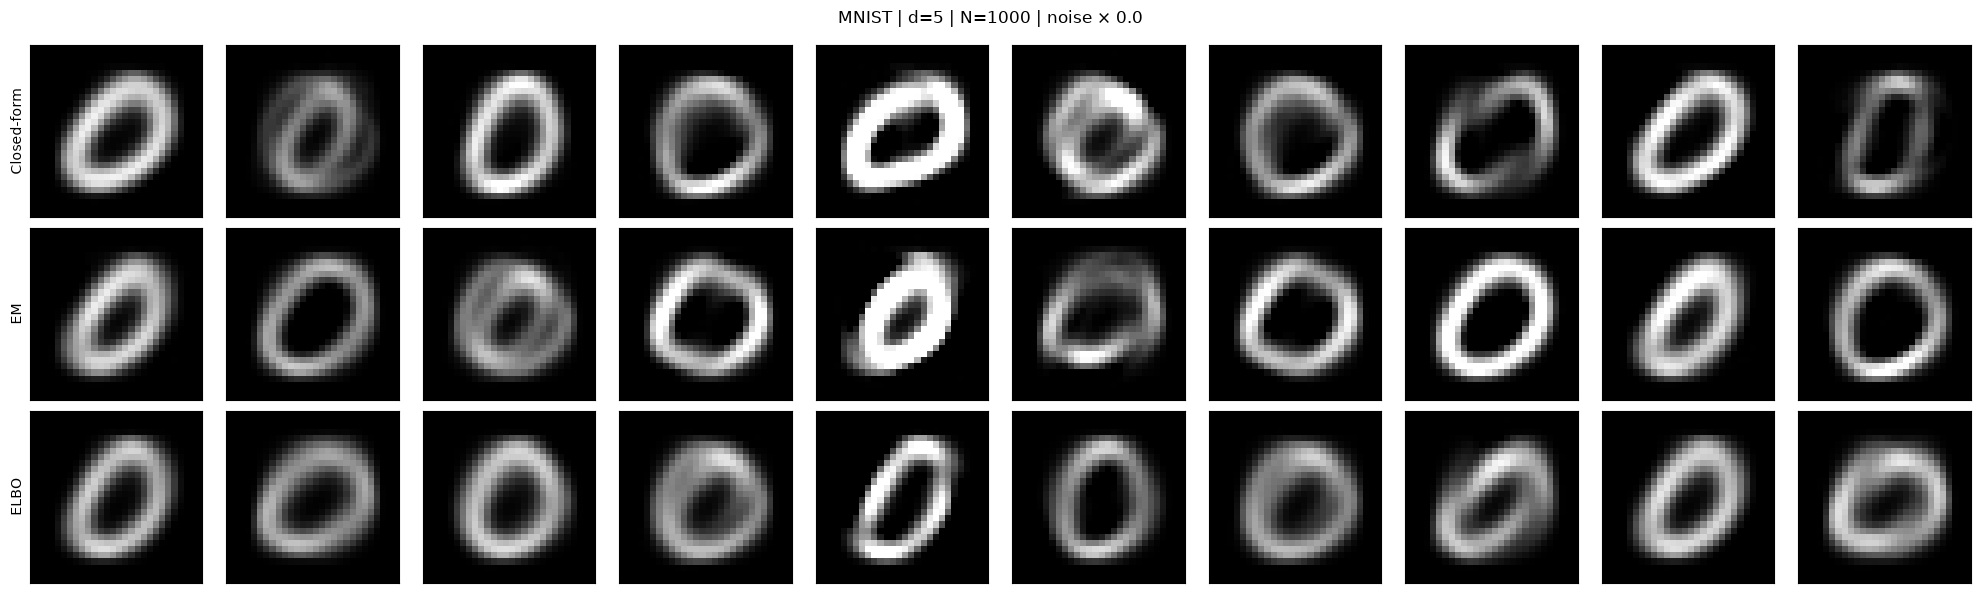

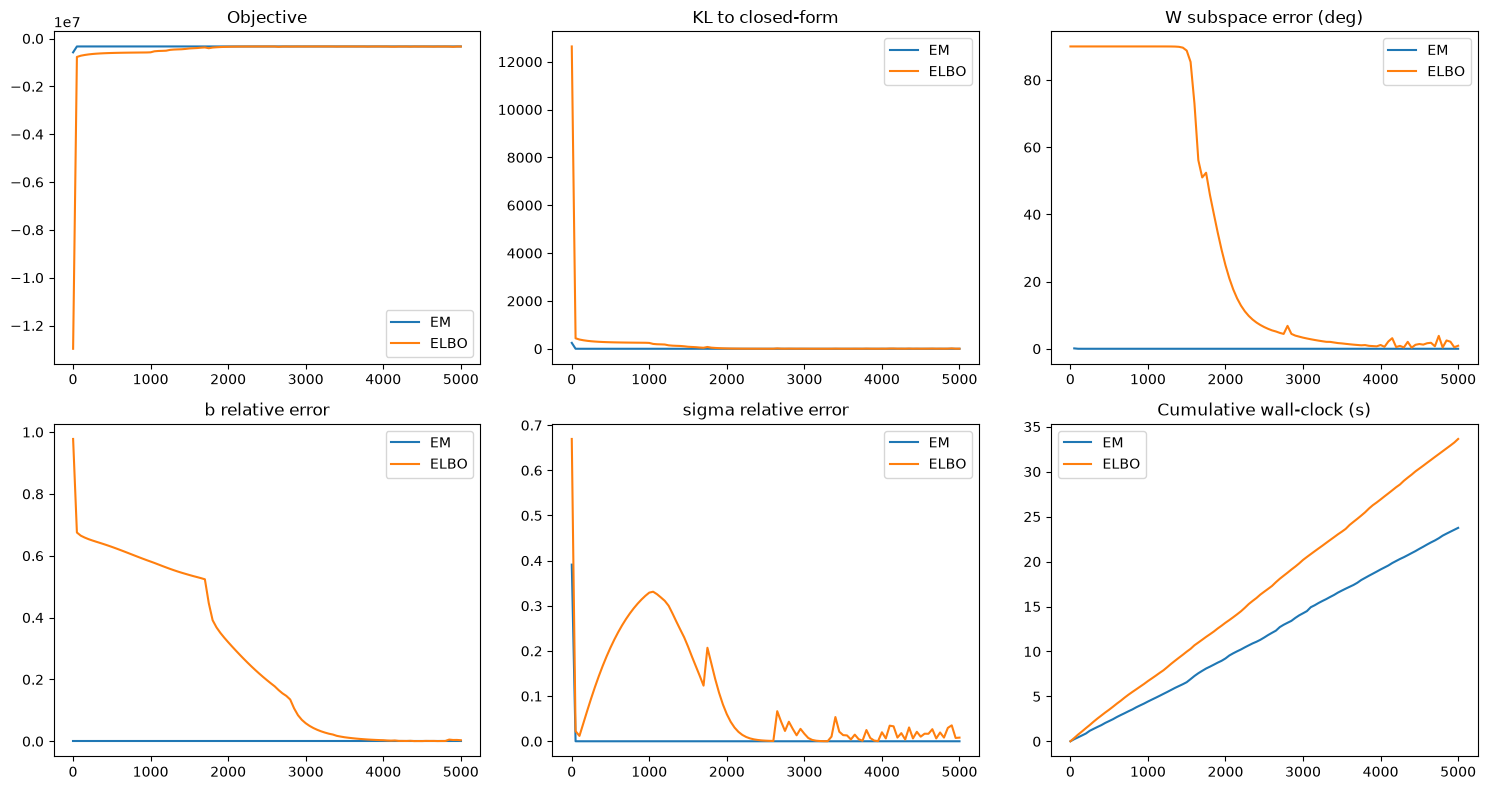

{'config': {'dataset': 'MNIST',
  'root': '../../data',
  'classes': [0],
  'limit_n_samples': 1000,
  'samples_per_class': None,
  'latent_dimension': 5,
  'noise_level': 0.0,
  'n_generated': 10,
  'em_iterations': 5000,
  'elbo_iterations': 5000,
  'learning_rate': 0.02,
  'seed': 0,
  'sigma_min': 0.0001,
  'metric_every': 50,
  'show_plots': True,
  'plot_start': 500},
 'X': tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]], dtype=torch.float64),
 'y': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
# Better Gradient Ascent

_ = run_experiment({**CONFIG, "learning_rate": 0.02, "elbo_iterations": 5000, "latent_dimension": 5})


MNIST | N=6000, D=784, d=2
Class counts: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000}
Fitting EM...
Fitting ELBO...

Sanity checks (summed objectives):
Closed-form  log-likelihood: -3149592.488700; per sample: -524.932081
EM           log-likelihood: -3149592.488700; per sample: -524.932081
ELBO         log-likelihood: -3150660.140763; per sample: -525.110023
Reference exact-posterior ELBO: -3149592.488700; LL gap: 4.66e-10
Learned encoder ELBO: -3150664.933993


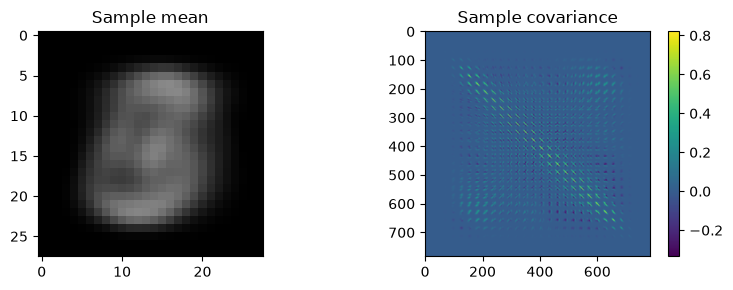

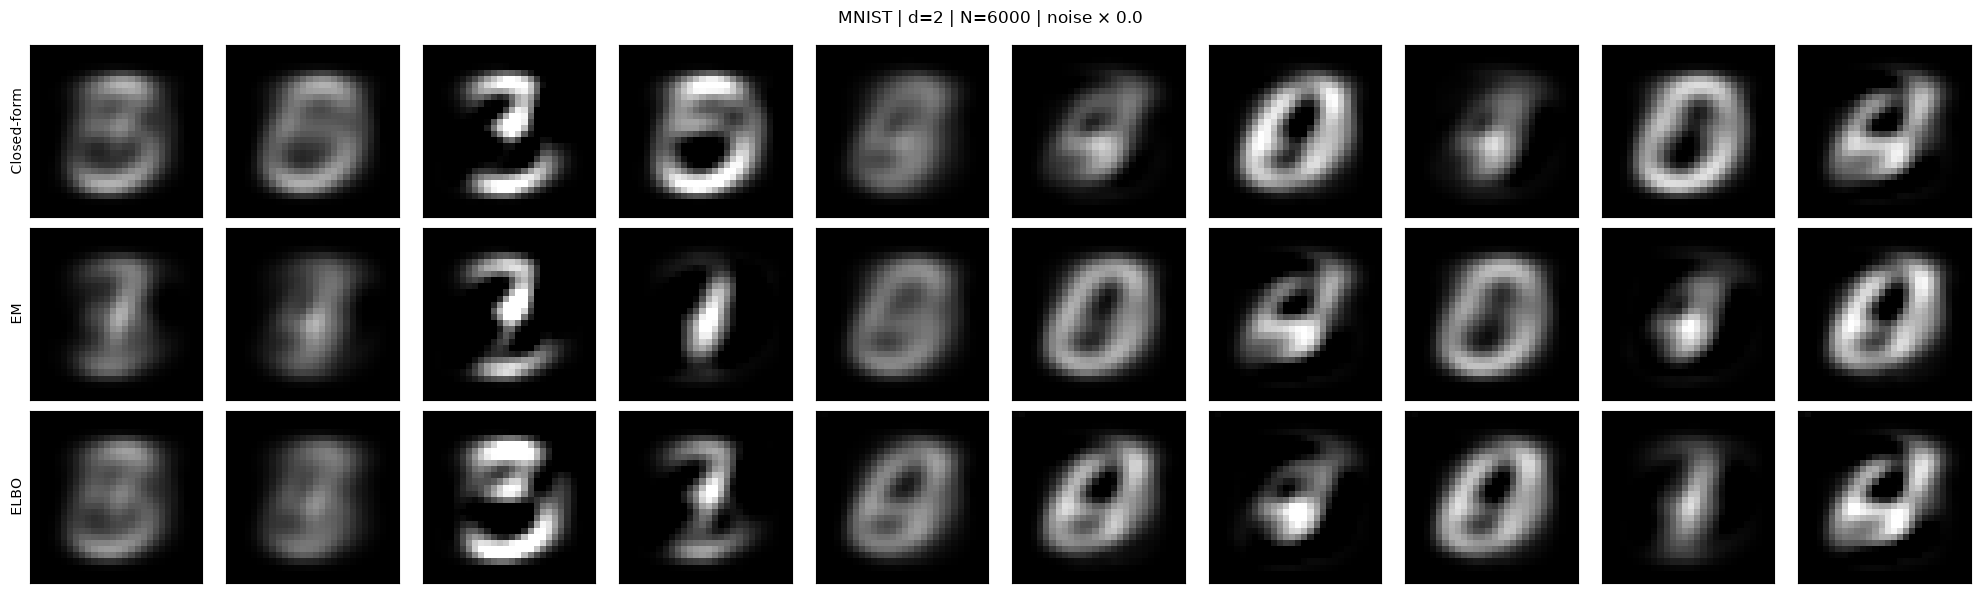

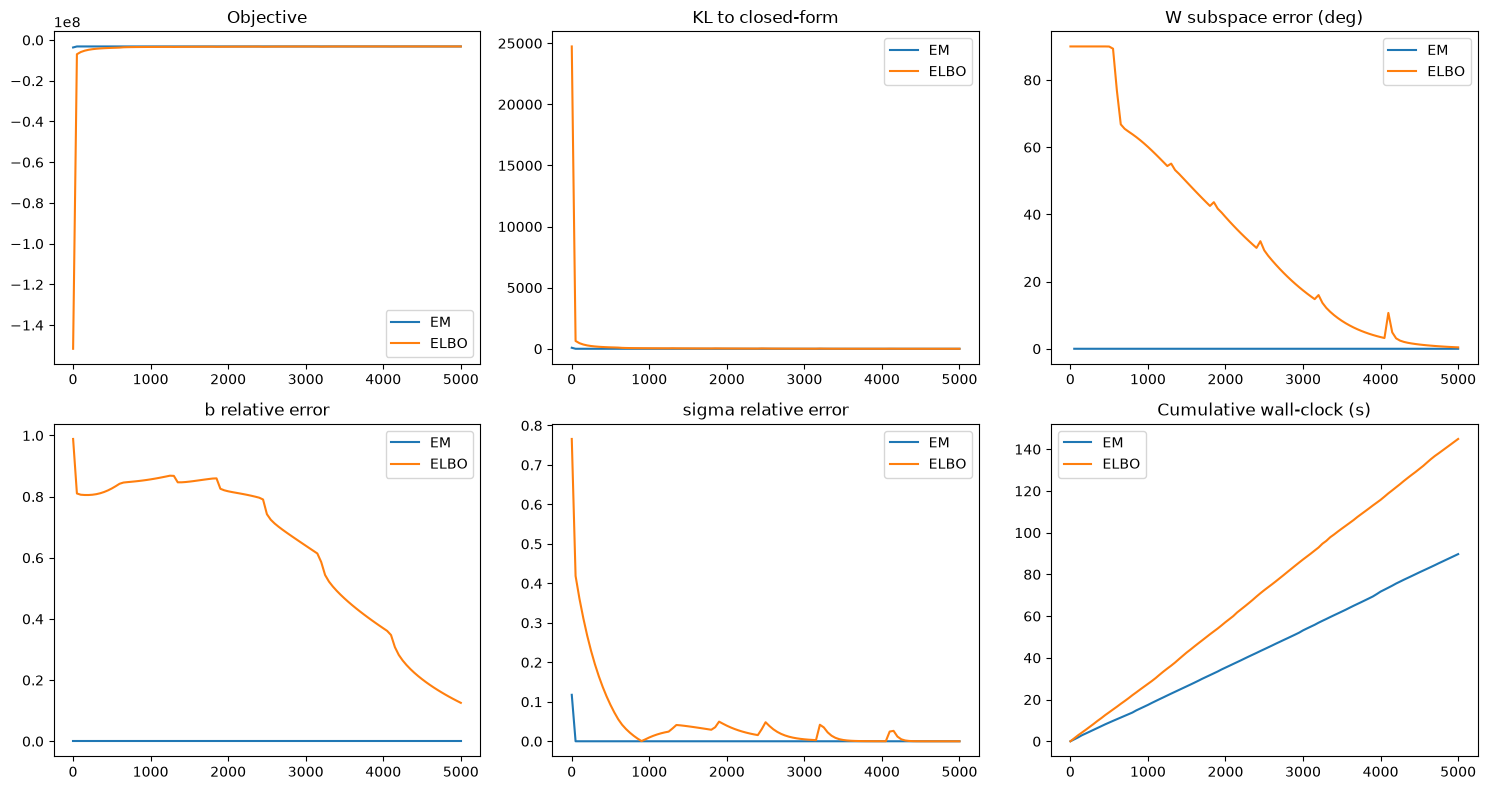

{'config': {'dataset': 'MNIST',
  'root': '../../data',
  'classes': [0, 1, 2, 3, 4, 5],
  'limit_n_samples': None,
  'samples_per_class': 1000,
  'latent_dimension': 2,
  'noise_level': 0.0,
  'n_generated': 10,
  'em_iterations': 5000,
  'elbo_iterations': 5000,
  'learning_rate': 0.01,
  'seed': 0,
  'sigma_min': 0.0001,
  'metric_every': 50,
  'show_plots': True,
  'plot_start': 500},
 'X': tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]], dtype=torch.float64),
 'y': tensor([0, 2, 1,  ..., 2, 3, 0]),
 'models': {'Closed-form': {'W': tensor([[0., 0.],
           [0., 0.],
           [0., 0.],
           ...,
           [0., 0.],
           [0., 0.],
           [0., 0.]], dtype=torch.float64),
   'b': tensor([-1.0000e+00, -1.0000e+00, -1.0000

In [ ]:
# Better Gradient Ascent

# CONFIG = {
#     **DEFAULT_CONFIG,
#     "dataset": "MNIST",
#     "root": "../../data",
#     "classes": [0],
#     "limit_n_samples": 1000,
#     "latent_dimension": 2,
#     "noise_level": 0.0,
#     "n_generated": 10,
#     "em_iterations": 5000,
#     "elbo_iterations": 5000,
#     "learning_rate": 1e-3,
#     "metric_every": 50,
#     "plot_start": 500,
#     "seed": 0,
# }

_ = run_experiment({**CONFIG, "learning_rate": 0.01, "classes": [0, 1, 2, 3, 4, 5], "limit_n_samples": None, "samples_per_class": 1000})